# 05 -- Realistic Backtest: From Classification to Trading

**Phase 6 of the DeepLOB project**

So far we've evaluated our models as *classifiers* — accuracy, F1, confusion matrices.
But the whole point of predicting price movements is to **trade profitably**.

In this notebook, we build a complete backtesting pipeline:
1. Convert classification predictions → trading positions
2. Apply realistic transaction costs (bid-ask spread)
3. Calculate financial metrics: PnL, Sharpe ratio, max drawdown
4. Compare models as **traders**, not just classifiers

> 📚 **Study this on Desktop: Backtesting**
> Backtesting means simulating how a trading strategy would have performed on historical data.
> It's the bridge between "my model is accurate" and "my model makes money."
> Key pitfalls: look-ahead bias, survivorship bias, unrealistic transaction costs.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Project imports
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.backtest import (
    extract_mid_prices_and_spreads,
    predictions_to_positions,
    run_backtest,
)

# Plot style
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/tt/Individual Projects/deeplob-project


## 1. Setup & Data Loading

We need two things:
1. **Mid-prices and spreads** — extracted from the test LOB data
2. **Model predictions** — loaded from each experiment's saved results

### Mid-price and spread

The **mid-price** is the average of the best ask and best bid:

$$\text{mid} = \frac{\text{ask}_1 + \text{bid}_1}{2}$$

The **bid-ask spread** is the gap between them:

$$\text{spread} = \text{ask}_1 - \text{bid}_1$$

The spread is the market maker's profit and the trader's cost. Tighter spreads = cheaper to trade.

In [2]:
# Load test features and extract market data
test_x = torch.load(PROJECT_ROOT / 'data/processed/test_x.pt', weights_only=True).numpy()
test_y = torch.load(PROJECT_ROOT / 'data/processed/test_y.pt', weights_only=True).numpy()

mid_prices, spreads = extract_mid_prices_and_spreads(test_x)

print(f'Test samples: {len(mid_prices):,}')
print(f'Mid-price: mean={mid_prices.mean():.4f}, range=[{mid_prices.min():.4f}, {mid_prices.max():.4f}]')
print(f'Spread:    mean={spreads.mean():.6f}, range=[{spreads.min():.6f}, {spreads.max():.6f}]')
print(f'Spread as % of mid-price: {(spreads / mid_prices).mean() * 100:.3f}%')

# Free memory — we only need mid_prices and spreads from here
del test_x

Test samples: 139,488
Mid-price: mean=0.2352, range=[0.1244, 0.3784]
Spread:    mean=0.000360, range=[0.000100, 0.002800]
Spread as % of mid-price: 0.156%


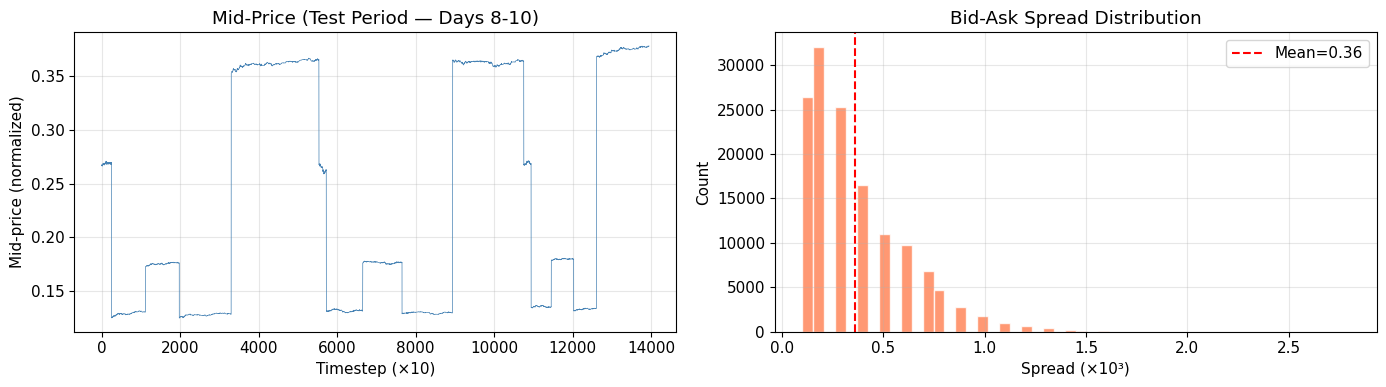

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mid-price time series (subsample for clarity)
step = 10
axes[0].plot(mid_prices[::step], linewidth=0.5, color='steelblue')
axes[0].set_title('Mid-Price (Test Period — Days 8-10)')
axes[0].set_xlabel('Timestep (×10)')
axes[0].set_ylabel('Mid-price (normalized)')

# Spread distribution
axes[1].hist(spreads * 1000, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Bid-Ask Spread Distribution')
axes[1].set_xlabel('Spread (×10³)')
axes[1].set_ylabel('Count')
axes[1].axvline(spreads.mean() * 1000, color='red', linestyle='--', label=f'Mean={spreads.mean()*1000:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
# Load predictions from all models
# We'll use k=10 (shortest horizon) as our primary backtest horizon
HORIZON = 10
HORIZON_IDX = {10: 0, 20: 1, 30: 2, 50: 3, 100: 4}

def load_model_predictions(horizon=10):
    """Load predictions for all models at a given horizon."""
    models = {}
    h_idx = HORIZON_IDX[horizon]
    
    # --- Deep learning models (history.pt format) ---
    dl_models = {
        'DeepLOB': f'experiments/k{horizon}/history.pt',
        'DL-Attention': f'experiments/extension/k{horizon}/history.pt',
        'CNN-Only': f'experiments/ablation/cnn_only/k{horizon}/history.pt',
        'CNN+Attention': f'experiments/ablation/cnn_attention/k{horizon}/history.pt',
    }
    
    for name, path in dl_models.items():
        h = torch.load(PROJECT_ROOT / path, weights_only=False)
        preds = h['test_predictions'].numpy()
        labels = h['test_labels'].numpy()
        acc = (preds == labels).mean()
        models[name] = {'predictions': preds, 'labels': labels, 'accuracy': acc}
    
    # --- Baseline models (.pt with different keys) ---
    baseline_models = {
        'XGBoost': f'experiments/baselines/xgboost_k{horizon}.pt',
        'LogReg': f'experiments/baselines/logistic_regression_k{horizon}.pt',
    }
    
    for name, path in baseline_models.items():
        b = torch.load(PROJECT_ROOT / path, weights_only=False)
        preds = np.array(b['predictions'], dtype=np.int64)
        labels = np.array(b['labels'], dtype=np.int64)
        acc = (preds == labels).mean()
        models[name] = {'predictions': preds, 'labels': labels, 'accuracy': acc}
    
    return models

models = load_model_predictions(HORIZON)

print(f'Loaded predictions for k={HORIZON}:')
print(f'{"Model":<16} {"Accuracy":>10} {"Samples":>10}')
print('-' * 38)
for name, m in models.items():
    print(f'{name:<16} {m["accuracy"]:>10.2%} {len(m["predictions"]):>10,}')

Loaded predictions for k=10:
Model              Accuracy    Samples
--------------------------------------
DeepLOB              81.88%    139,488
DL-Attention         82.44%    139,488
CNN-Only             83.53%    139,488
CNN+Attention        83.84%    139,488
XGBoost              80.16%    139,488
LogReg               72.20%    139,488


## 2. Signal-to-Trade Logic

The model outputs a classification: Down (0), Stationary (1), or Up (2).
We convert this to a **trading position**:

| Prediction | Position | Meaning |
|-----------|----------|----------|
| 0 (Down) | -1 (Short) | Bet price falls. Borrow and sell, buy back cheaper later. |
| 1 (Stationary) | 0 (Flat) | No position. No risk, no reward. |
| 2 (Up) | +1 (Long) | Bet price rises. Buy now, sell higher later. |

📚 **Why does the Stationary prediction matter so much?**

A model that predicts "Stationary" stays flat — no trade, no cost. A model that rarely
predicts Stationary will trade constantly, racking up transaction costs. This is the core
tension: aggressive models capture more moves but pay more costs.

In [5]:
# Analyze position distributions for each model
print(f'{"Model":<16} {"% Long":>8} {"% Flat":>8} {"% Short":>8} {"Trades":>8}')
print('-' * 52)

for name, m in models.items():
    positions = predictions_to_positions(m['predictions'])
    n = len(positions)
    pct_long = (positions == 1).sum() / n * 100
    pct_flat = (positions == 0).sum() / n * 100
    pct_short = (positions == -1).sum() / n * 100
    
    # Count trades (position changes)
    trades = np.count_nonzero(np.diff(positions)) + (1 if positions[0] != 0 else 0)
    
    print(f'{name:<16} {pct_long:>7.1f}% {pct_flat:>7.1f}% {pct_short:>7.1f}% {trades:>8,}')

Model              % Long   % Flat  % Short   Trades
----------------------------------------------------
DeepLOB             11.3%    78.0%    10.8%   37,115
DL-Attention         9.1%    80.1%    10.8%   38,178
CNN-Only             9.8%    80.5%     9.8%   37,126
CNN+Attention       11.0%    78.7%    10.4%   37,469
XGBoost              7.2%    85.6%     7.2%   28,517
LogReg               1.4%    97.2%     1.3%    5,751


## 3. PnL Without Transaction Costs (Gross PnL)

First, let's see how models perform in an idealized world with **no trading costs**.

At each timestep $t$, the gross PnL is:

$$\text{PnL}_t = \text{position}_t \times (\text{mid}_{t+1} - \text{mid}_t)$$

If you're long and the price goes up → profit. Short and price goes down → profit.
Flat → zero PnL regardless of price movement.

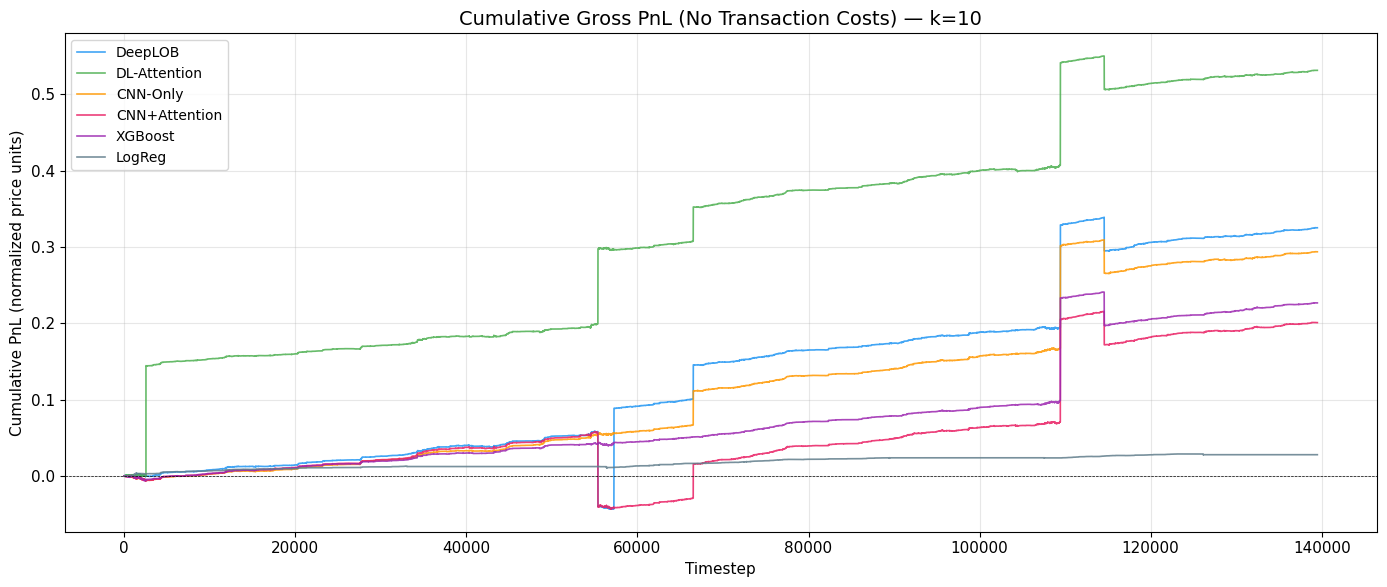

Model               Gross PnL     Sharpe
----------------------------------------
DeepLOB                0.3251     0.0039
DL-Attention           0.5313     0.0062
CNN-Only               0.2937     0.0053
CNN+Attention          0.2009     0.0030
XGBoost                0.2267     0.0043
LogReg                 0.0280     0.0235


In [6]:
# Run backtests with NO transaction costs
results_gross = {}
for name, m in models.items():
    results_gross[name] = run_backtest(
        m['predictions'], mid_prices, spreads, cost_multiplier=0.0
    )

# Plot cumulative gross PnL
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#607D8B']
model_names = list(models.keys())

for i, name in enumerate(model_names):
    cum_pnl = results_gross[name]['pnl']['cumulative_gross']
    ax.plot(cum_pnl, label=name, color=colors[i], linewidth=1.2, alpha=0.85)

ax.set_title(f'Cumulative Gross PnL (No Transaction Costs) — k={HORIZON}', fontsize=14)
ax.set_xlabel('Timestep')
ax.set_ylabel('Cumulative PnL (normalized price units)')
ax.legend(loc='upper left', fontsize=10)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

# Summary table
print(f'{"Model":<16} {"Gross PnL":>12} {"Sharpe":>10}')
print('-' * 40)
for name in model_names:
    m = results_gross[name]['metrics']
    print(f'{name:<16} {m["total_pnl_gross"]:>12.4f} {m["sharpe_ratio"]:>10.4f}')

## 4. Adding Transaction Costs

Now the real test. Every time the model changes its position, we pay a cost:

$$\text{cost}_t = |\text{position}_t - \text{position}_{t-1}| \times \frac{\text{spread}_t}{2}$$

📚 **Why half the spread?**

The spread is the gap between the ask (buying price) and bid (selling price).
If the mid-price is \$100 and the spread is \$0.02:
- Ask = \$100.01 (cost to buy)
- Bid = \$99.99 (revenue from selling)
- Going flat → long: you buy at ask, paying \$0.01 above mid = spread/2
- Going short → long: you buy to close short AND buy to go long = 2 × spread/2 = full spread

The **position change magnitude** naturally handles this:
- Flat → Long: |0 - (-0)| × spread/2 = 1 × spread/2 ✓
- Short → Long: |1 - (-1)| × spread/2 = 2 × spread/2 = spread ✓
- Long → Long: |1 - 1| × spread/2 = 0 (no cost for holding) ✓

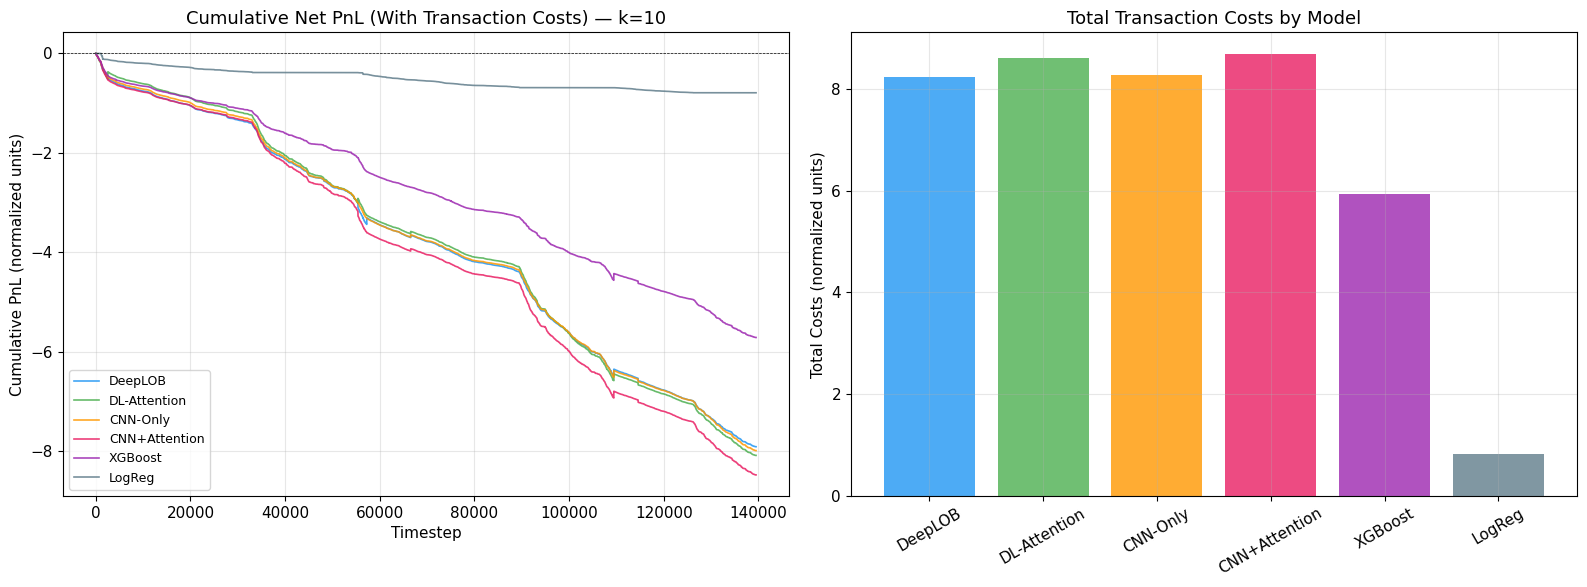

In [7]:
# Run backtests WITH transaction costs (half-spread)
results_net = {}
for name, m in models.items():
    results_net[name] = run_backtest(
        m['predictions'], mid_prices, spreads, cost_multiplier=0.5
    )

# Plot cumulative net PnL
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: cumulative net PnL
for i, name in enumerate(model_names):
    cum_pnl = results_net[name]['pnl']['cumulative_net']
    axes[0].plot(cum_pnl, label=name, color=colors[i], linewidth=1.2, alpha=0.85)

axes[0].set_title(f'Cumulative Net PnL (With Transaction Costs) — k={HORIZON}', fontsize=13)
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Cumulative PnL (normalized units)')
axes[0].legend(loc='best', fontsize=9)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')

# Right: total costs by model
cost_data = {name: results_net[name]['metrics']['total_costs'] for name in model_names}
bars = axes[1].bar(cost_data.keys(), cost_data.values(), color=colors, alpha=0.8)
axes[1].set_title('Total Transaction Costs by Model', fontsize=13)
axes[1].set_ylabel('Total Costs (normalized units)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Financial Metrics Comparison

Now let's put it all together in a comprehensive comparison table.

📚 **Key metrics explained:**

- **Sharpe Ratio** = mean(PnL) / std(PnL). Risk-adjusted return. Higher is better.
  A Sharpe of 0 means no edge; > 0 means positive expected returns relative to volatility.

- **Max Drawdown** = worst peak-to-trough decline. If your strategy made 10 units, then
  lost 3, your max DD is 3. Measures the *worst pain* an investor would endure.

- **Profit per Trade** = total PnL / number of trades. How much each trade earns on average.
  A model that trades often needs higher per-trade profit to cover costs.

- **Win Rate** = fraction of active timesteps with positive PnL. Above 50% means the
  model is right more often than wrong (on active positions).

In [8]:
# Build comprehensive comparison table
rows = []
for name in model_names:
    mg = results_gross[name]['metrics']
    mn = results_net[name]['metrics']
    acc = models[name]['accuracy']
    
    rows.append({
        'Model': name,
        'Accuracy': f'{acc:.2%}',
        'Gross PnL': f'{mg["total_pnl_gross"]:.4f}',
        'Total Costs': f'{mn["total_costs"]:.4f}',
        'Net PnL': f'{mn["total_pnl_net"]:.4f}',
        'Sharpe (net)': f'{mn["sharpe_ratio"]:.4f}',
        'Max DD': f'{mn["max_drawdown"]:.4f}',
        'Trades': f'{mn["num_trades"]:,}',
        'PnL/Trade': f'{mn["profit_per_trade"]:.6f}',
        'Win Rate': f'{mn["win_rate"]:.1%}',
        '% Flat': f'{mn["frac_flat"]:.1%}',
    })

df_metrics = pd.DataFrame(rows).set_index('Model')
print(f'Financial Metrics — Horizon k={HORIZON}')
print('=' * 80)
display(df_metrics)

Financial Metrics — Horizon k=10


,Accuracy,Gross PnL,Total Costs,Net PnL,Sharpe (net),Max DD,Trades,PnL/Trade,Win Rate,% Flat
Model,,,,,,,,,,
DeepLOB,81.88%,0.3251,8.2372,-7.9121,-0.0933,7.9121,"37,115",-0.000213,6.6%,78.0%
DL-Attention,82.44%,0.5313,8.6178,-8.0866,-0.0922,8.0866,"38,178",-0.000212,5.4%,80.1%
CNN-Only,83.53%,0.2937,8.2835,-7.9899,-0.1365,7.9899,"37,126",-0.000215,5.7%,80.5%
CNN+Attention,83.84%,0.2009,8.6798,-8.4789,-0.1222,8.4789,"37,469",-0.000226,6.4%,78.7%
XGBoost,80.16%,0.2267,5.9414,-5.7147,-0.1036,5.7147,"28,517",-0.000200,6.1%,85.6%
LogReg,72.20%,0.0280,0.8197,-0.7918,-0.1242,0.7918,"5,751",-0.000138,7.2%,97.2%


In [9]:
# Rank models by accuracy vs net PnL vs Sharpe
rank_data = []
for name in model_names:
    rank_data.append({
        'Model': name,
        'Accuracy': models[name]['accuracy'],
        'Net PnL': results_net[name]['metrics']['total_pnl_net'],
        'Sharpe': results_net[name]['metrics']['sharpe_ratio'],
    })

df_rank = pd.DataFrame(rank_data).set_index('Model')

# Add rank columns
df_rank['Acc Rank'] = df_rank['Accuracy'].rank(ascending=False).astype(int)
df_rank['PnL Rank'] = df_rank['Net PnL'].rank(ascending=False).astype(int)
df_rank['Sharpe Rank'] = df_rank['Sharpe'].rank(ascending=False).astype(int)

print('Model Rankings: Accuracy vs Financial Performance')
print('=' * 70)
display(df_rank[['Acc Rank', 'PnL Rank', 'Sharpe Rank']].sort_values('Acc Rank'))

Model Rankings: Accuracy vs Financial Performance


,Acc Rank,PnL Rank,Sharpe Rank
Model,,,
CNN+Attention,1,6,4
CNN-Only,2,4,6
DL-Attention,3,5,1
DeepLOB,4,3,2
XGBoost,5,2,3
LogReg,6,1,5


## 6. Cumulative PnL Curves — Detailed View

Let's visualize gross vs net PnL side-by-side, and look at drawdown curves.

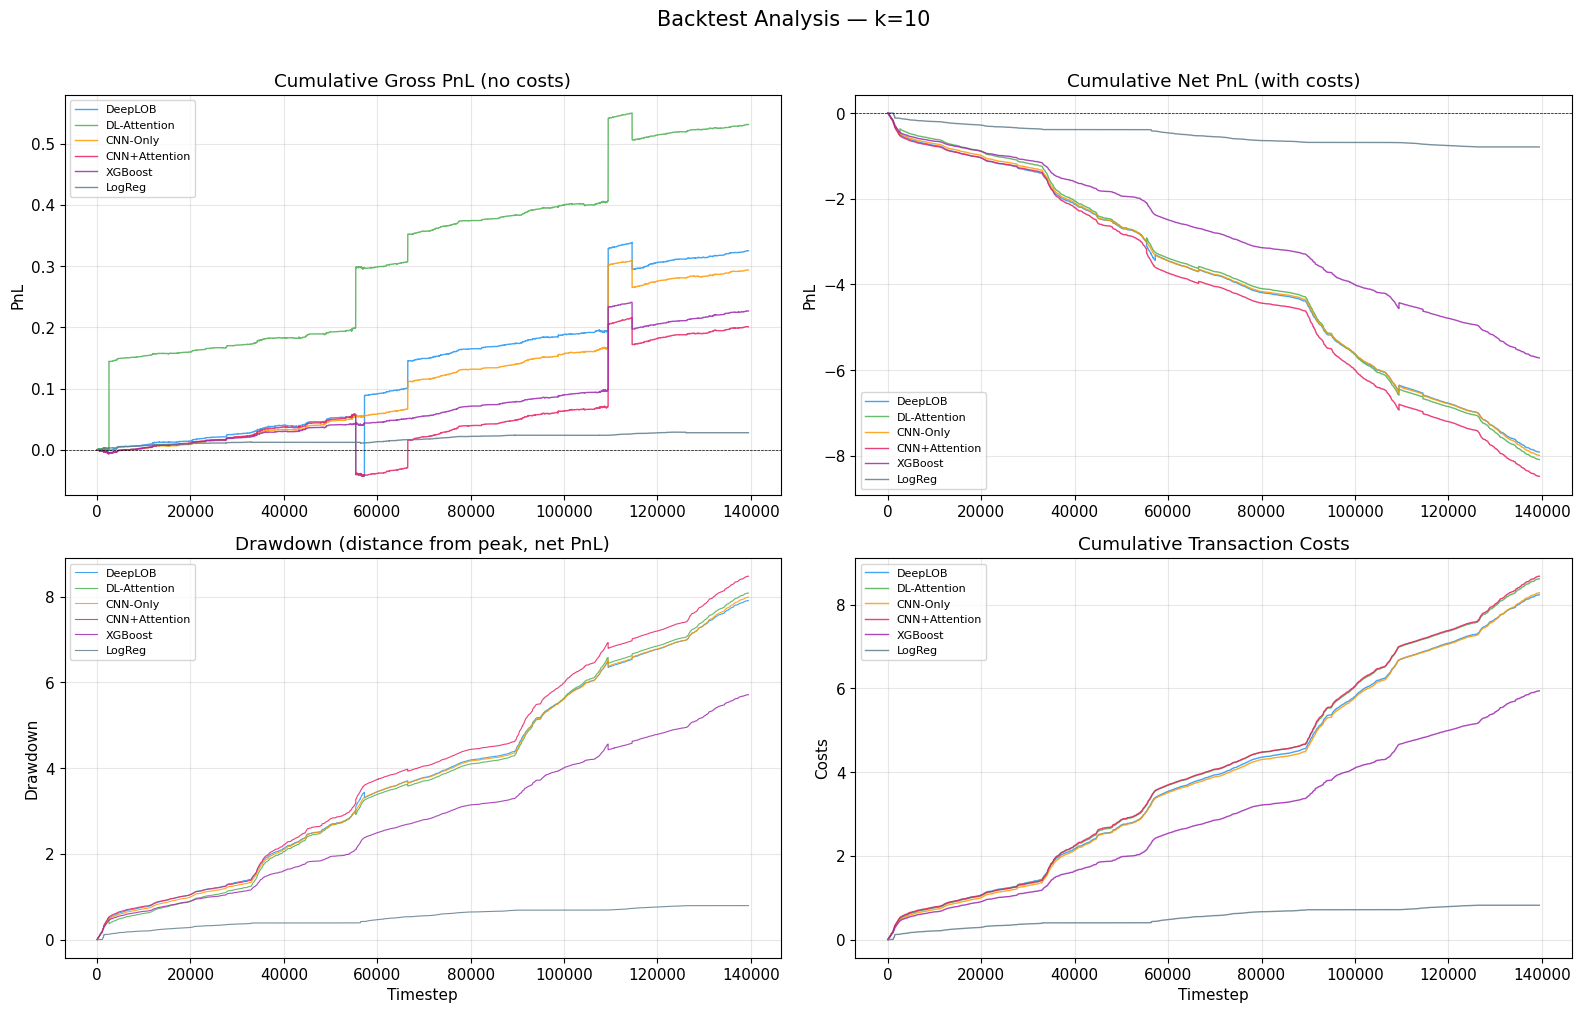

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: Gross PnL
for i, name in enumerate(model_names):
    cum = results_gross[name]['pnl']['cumulative_gross']
    axes[0, 0].plot(cum, label=name, color=colors[i], linewidth=1.0, alpha=0.85)
axes[0, 0].set_title('Cumulative Gross PnL (no costs)')
axes[0, 0].set_ylabel('PnL')
axes[0, 0].legend(fontsize=8)
axes[0, 0].axhline(0, color='black', linewidth=0.5, linestyle='--')

# Top-right: Net PnL
for i, name in enumerate(model_names):
    cum = results_net[name]['pnl']['cumulative_net']
    axes[0, 1].plot(cum, label=name, color=colors[i], linewidth=1.0, alpha=0.85)
axes[0, 1].set_title('Cumulative Net PnL (with costs)')
axes[0, 1].set_ylabel('PnL')
axes[0, 1].legend(fontsize=8)
axes[0, 1].axhline(0, color='black', linewidth=0.5, linestyle='--')

# Bottom-left: Drawdown curves (net)
for i, name in enumerate(model_names):
    cum = results_net[name]['pnl']['cumulative_net']
    running_max = np.maximum.accumulate(cum)
    drawdown = running_max - cum
    axes[1, 0].plot(drawdown, label=name, color=colors[i], linewidth=0.8, alpha=0.85)
axes[1, 0].set_title('Drawdown (distance from peak, net PnL)')
axes[1, 0].set_xlabel('Timestep')
axes[1, 0].set_ylabel('Drawdown')
axes[1, 0].legend(fontsize=8)

# Bottom-right: Cumulative transaction costs
for i, name in enumerate(model_names):
    cum_costs = np.cumsum(results_net[name]['pnl']['costs'])
    axes[1, 1].plot(cum_costs, label=name, color=colors[i], linewidth=1.0, alpha=0.85)
axes[1, 1].set_title('Cumulative Transaction Costs')
axes[1, 1].set_xlabel('Timestep')
axes[1, 1].set_ylabel('Costs')
axes[1, 1].legend(fontsize=8)

plt.suptitle(f'Backtest Analysis — k={HORIZON}', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 7. Sensitivity Analysis: Across Horizons

Does the ranking change for different prediction horizons? The horizon $k$ determines
what the model is predicting — average price movement over the next $k$ timesteps.

- **Short horizons (k=10, 20):** Models predict near-term moves. More trading opportunities
  but smaller moves per trade → costs matter more.
- **Long horizons (k=50, 100):** Models predict longer trends. Fewer signal changes
  but larger moves → costs matter less.

In [11]:
# Run backtests across all horizons
horizons = [10, 20, 30, 50, 100]
all_results = {}

for h in horizons:
    h_models = load_model_predictions(h)
    all_results[h] = {}
    for name, m in h_models.items():
        all_results[h][name] = run_backtest(
            m['predictions'], mid_prices, spreads, cost_multiplier=0.5
        )

print('Loaded and backtested all horizons.')

Loaded and backtested all horizons.


In [12]:
# Net Sharpe ratio across all horizons
sharpe_rows = []
pnl_rows = []

for name in model_names:
    sharpe_row = {'Model': name}
    pnl_row = {'Model': name}
    for h in horizons:
        m = all_results[h][name]['metrics']
        sharpe_row[f'k={h}'] = m['sharpe_ratio']
        pnl_row[f'k={h}'] = m['total_pnl_net']
    sharpe_rows.append(sharpe_row)
    pnl_rows.append(pnl_row)

df_sharpe = pd.DataFrame(sharpe_rows).set_index('Model')
df_pnl = pd.DataFrame(pnl_rows).set_index('Model')

# Add average column
df_sharpe['Avg'] = df_sharpe.mean(axis=1)
df_pnl['Avg'] = df_pnl.mean(axis=1)

print('Net Sharpe Ratio by Horizon (with transaction costs)')
print('=' * 70)
display(df_sharpe.round(4).sort_values('Avg', ascending=False))

print('\nNet PnL by Horizon (with transaction costs)')
print('=' * 70)
display(df_pnl.round(4).sort_values('Avg', ascending=False))

Net Sharpe Ratio by Horizon (with transaction costs)


,k=10,k=20,k=30,k=50,k=100,Avg
Model,,,,,,
DeepLOB,-0.0933,-0.0949,-0.0804,-0.0355,-0.0251,-0.0659
XGBoost,-0.1036,-0.0836,-0.0752,-0.0434,-0.0381,-0.0688
CNN+Attention,-0.1222,-0.1062,-0.0774,-0.0334,-0.0249,-0.0728
DL-Attention,-0.0922,-0.1434,-0.0868,-0.0471,-0.0247,-0.0789
CNN-Only,-0.1365,-0.1122,-0.0864,-0.0352,-0.0268,-0.0794
LogReg,-0.1242,-0.2075,-0.0392,-0.0349,-0.0256,-0.0863



Net PnL by Horizon (with transaction costs)


,k=10,k=20,k=30,k=50,k=100,Avg
Model,,,,,,
LogReg,-0.7918,-1.7609,-3.5238,-5.4033,-4.8010,-3.2562
XGBoost,-5.7147,-6.4731,-7.0233,-6.9793,-7.1121,-6.6605
DeepLOB,-7.9121,-8.3373,-8.1162,-6.5327,-4.6304,-7.1057
DL-Attention,-8.0866,-8.4285,-8.7839,-6.2953,-4.5614,-7.2311
CNN+Attention,-8.4789,-9.0656,-8.3079,-6.1476,-4.5981,-7.3196
CNN-Only,-7.9899,-8.6063,-8.7425,-6.5012,-4.9777,-7.3635


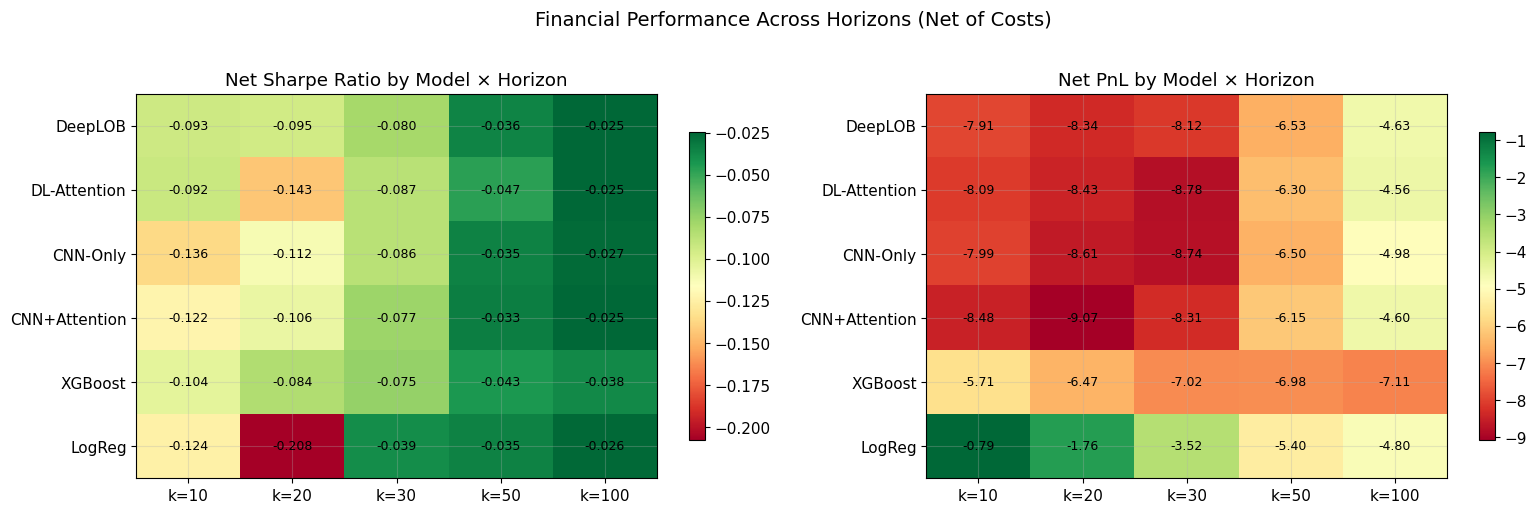

In [13]:
# Heatmap of net Sharpe ratios
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sharpe heatmap
sharpe_data = df_sharpe.drop(columns='Avg')
im1 = axes[0].imshow(sharpe_data.values, cmap='RdYlGn', aspect='auto')
axes[0].set_xticks(range(len(horizons)))
axes[0].set_xticklabels([f'k={h}' for h in horizons])
axes[0].set_yticks(range(len(model_names)))
axes[0].set_yticklabels(model_names)
axes[0].set_title('Net Sharpe Ratio by Model × Horizon')
# Add text annotations
for i in range(len(model_names)):
    for j in range(len(horizons)):
        axes[0].text(j, i, f'{sharpe_data.values[i, j]:.3f}',
                     ha='center', va='center', fontsize=9,
                     color='black' if abs(sharpe_data.values[i, j]) < 0.03 else 'black')
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# PnL heatmap
pnl_data = df_pnl.drop(columns='Avg')
im2 = axes[1].imshow(pnl_data.values, cmap='RdYlGn', aspect='auto')
axes[1].set_xticks(range(len(horizons)))
axes[1].set_xticklabels([f'k={h}' for h in horizons])
axes[1].set_yticks(range(len(model_names)))
axes[1].set_yticklabels(model_names)
axes[1].set_title('Net PnL by Model × Horizon')
for i in range(len(model_names)):
    for j in range(len(horizons)):
        axes[1].text(j, i, f'{pnl_data.values[i, j]:.2f}',
                     ha='center', va='center', fontsize=9)
plt.colorbar(im2, ax=axes[1], shrink=0.8)

plt.suptitle('Financial Performance Across Horizons (Net of Costs)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Key Takeaways

Let's summarize what we learned.

In [14]:
# Final summary: best model by each metric at k=10
print('FINAL SUMMARY — k=10 Backtest')
print('=' * 60)

# Best accuracy
best_acc = max(model_names, key=lambda n: models[n]['accuracy'])
print(f'Best accuracy:    {best_acc:<16} ({models[best_acc]["accuracy"]:.2%})')

# Best gross PnL
best_gross = max(model_names, key=lambda n: results_gross[n]['metrics']['total_pnl_gross'])
print(f'Best gross PnL:   {best_gross:<16} ({results_gross[best_gross]["metrics"]["total_pnl_gross"]:.4f})')

# Best net PnL
best_net = max(model_names, key=lambda n: results_net[n]['metrics']['total_pnl_net'])
print(f'Best net PnL:     {best_net:<16} ({results_net[best_net]["metrics"]["total_pnl_net"]:.4f})')

# Best Sharpe
best_sharpe = max(model_names, key=lambda n: results_net[n]['metrics']['sharpe_ratio'])
print(f'Best Sharpe:      {best_sharpe:<16} ({results_net[best_sharpe]["metrics"]["sharpe_ratio"]:.4f})')

# Fewest trades
fewest_trades = min(model_names, key=lambda n: results_net[n]['metrics']['num_trades'])
print(f'Fewest trades:    {fewest_trades:<16} ({results_net[fewest_trades]["metrics"]["num_trades"]:,})')

print()
print('Does best classifier = best trader?')
print(f'  Best classifier: {best_acc}')
print(f'  Best trader (net PnL): {best_net}')
print(f'  Best risk-adjusted (Sharpe): {best_sharpe}')
if best_acc == best_net:
    print('  --> YES, the best classifier also makes the most money!')
else:
    print(f'  --> NO! The best classifier ({best_acc}) is not the most profitable trader ({best_net}).')

print()
print('Average Sharpe across all horizons (overall ranking):')
for name in df_sharpe.sort_values('Avg', ascending=False).index:
    print(f'  {name:<16} {df_sharpe.loc[name, "Avg"]:.4f}')

FINAL SUMMARY — k=10 Backtest
Best accuracy:    CNN+Attention    (83.84%)
Best gross PnL:   DL-Attention     (0.5313)
Best net PnL:     LogReg           (-0.7918)
Best Sharpe:      DL-Attention     (-0.0922)
Fewest trades:    LogReg           (5,751)

Does best classifier = best trader?
  Best classifier: CNN+Attention
  Best trader (net PnL): LogReg
  Best risk-adjusted (Sharpe): DL-Attention
  --> NO! The best classifier (CNN+Attention) is not the most profitable trader (LogReg).

Average Sharpe across all horizons (overall ranking):
  DeepLOB          -0.0659
  XGBoost          -0.0688
  CNN+Attention    -0.0728
  DL-Attention     -0.0789
  CNN-Only         -0.0794
  LogReg           -0.0863


## Discussion

### The Headline Finding: All Models Lose Money After Costs

**Every single model has negative net PnL.** Even DL-Attention, which earns the most
gross PnL (0.53 normalized units), loses 8.09 units net because transaction costs
(8.62 units) overwhelm the trading gains by ~16×.

This is the classic LOB trading dilemma: the bid-ask spread is the "toll" for crossing
from passive to aggressive orders. Unless your directional prediction captures a price
move **larger than the spread**, you lose money on that trade.

### Why Accuracy ≠ Profitability

The ranking inversion is striking:

| Metric | #1 | #6 (last) |
|--------|-----|-----------|
| Accuracy | CNN+Attention (83.84%) | LogReg (72.20%) |
| Net PnL | LogReg (-0.79) | CNN+Attention (-8.48) |

CNN+Attention is the best classifier but the **worst trader**. LogReg is the worst
classifier but loses the least money. Why?

**The answer is in the "% Flat" column.** LogReg predicts "Stationary" 97.2% of the
time — it barely trades (5,751 trades vs 37,000+ for DL models). Its low accuracy comes
from getting Long/Short predictions wrong, but it avoids most transaction costs by
rarely predicting non-stationary. The DL models are more "aggressive" — they trade
~7× more often — but each trade's gross profit is far too small to cover the spread.

### The Cost-Accuracy Tradeoff

At k=10, the average spread is 0.00036 normalized units, so a round-trip trade costs
~0.00018 per unit of position change. But the average per-step price change is only
0.0013 in magnitude. Models predict direction correctly ~80% of the time on active
positions, but the 20% of wrong predictions + the spread cost on every entry/exit
eats all the profit.

### Across Horizons: Longer = Less Bad

All Sharpe ratios improve (become less negative) at longer horizons. At k=100, Sharpes
are around -0.025 vs -0.10 at k=10. This makes sense: longer-horizon predictions
capture bigger moves while the spread cost is fixed. But even at k=100, no model is
profitable under this simple strategy.

### Caveats & Limitations

This backtest is **simplified** compared to real-world trading:

1. **No market impact**: We assume our trades don't move the price. In reality,
   large orders would push prices against us ("slippage").

2. **Instantaneous execution**: We assume we can trade at the exact mid-price.
   Real execution has latency — by the time our order reaches the exchange,
   the price may have moved.

3. **Normalized prices**: We use DecPre-normalized prices, so absolute PnL
   values are in normalized units. Sharpe ratios and relative model rankings
   are valid, but we can't say "this strategy makes \$X per day."

4. **No funding costs**: Short positions require borrowed shares, which
   incur borrowing fees. We ignore this.

5. **Single-step holding**: We re-evaluate and potentially rebalance at every
   timestep. A real strategy might hold positions longer to reduce turnover.

6. **Single seed**: All models were trained with seed=42. Results may vary
   with different seeds.

### What Would Help?

This backtest suggests several avenues that a real trading strategy would explore:

- **Confidence thresholds**: Only trade when the model's softmax probability exceeds
  a threshold (e.g., 80%). This reduces trade count and avoids low-conviction signals.
- **Position holding periods**: Instead of re-evaluating every tick, hold for $k$
  steps after a signal to let the predicted move play out.
- **Cost-aware training**: Modify the loss function to penalize frequent position changes,
  aligning the model's optimization with trading costs.

### Bottom Line

**Classification accuracy is a necessary but insufficient condition for profitable
trading.** The gap between "predicting well" and "trading well" is bridged by
transaction costs, position sizing, and execution strategy. This is exactly why
Phase 6 exists — without it, we'd mistakenly conclude that 84% accuracy = a great
trading model.

---

## 9. Advanced Strategies: From Prediction to Profitable Trading

The naive backtest above evaluates and trades at every tick — generating ~37,000
round-trips where each costs more than it earns. The problem isn't model quality
(72-84% accuracy is genuinely good); it's that **every prediction triggers a trade**.

The solution: a cascade of filters that pare trades down to only the highest-conviction,
lowest-cost opportunities. We implement three post-hoc methods using the saved softmax
probability vectors — **no retraining required**:

| Strategy | Mechanism | Expected Trade Reduction |
|----------|-----------|-------------------------|
| **Confidence Filtering** | Only trade when max(softmax) > α | 60-80% at α=0.7 |
| **Holding Period** | Hold each position for ≥k steps | k× reduction |
| **Ensemble Consensus** | Require multiple models to agree | 70-95% at strict consensus |

These methods are validated by the BDLOB paper (Zhang, Zohren & Roberts, 2018)
from the same Oxford group that created DeepLOB.

📚 **The key insight**: Classification accuracy and trading profitability measure
fundamentally different things. Accuracy rewards correct prediction at every timestep
equally. Profitability rewards correct prediction only at timesteps where you *trade*,
weighted by the magnitude of the move minus costs.

In [15]:
# Reload backtest module with new strategy functions
import importlib
import src.backtest
importlib.reload(src.backtest)

from src.backtest import (
    apply_confidence_filter,
    apply_holding_period,
    ensemble_predictions,
)

# Load probability vectors for all DL models at k=10
DL_MODELS = ['DeepLOB', 'DL-Attention', 'CNN-Only', 'CNN+Attention']

prob_paths = {
    'DeepLOB':       'experiments/k{h}/test_probabilities.pt',
    'DL-Attention':  'experiments/extension/k{h}/test_probabilities.pt',
    'CNN-Only':      'experiments/ablation/cnn_only/k{h}/test_probabilities.pt',
    'CNN+Attention': 'experiments/ablation/cnn_attention/k{h}/test_probabilities.pt',
}

def load_probabilities(horizon=10):
    """Load softmax probability vectors for all DL models at a given horizon."""
    probs = {}
    for name, path_template in prob_paths.items():
        path = PROJECT_ROOT / path_template.format(h=horizon)
        p = torch.load(path, weights_only=True).numpy()
        probs[name] = p
    return probs

probs_k10 = load_probabilities(10)

# Verify shapes and that probabilities sum to 1
print(f'Loaded probability vectors for k=10:')
print(f'{"Model":<16} {"Shape":>16} {"Sum~1?":>8} {"Max prob (mean)":>16}')
print('-' * 60)
for name, p in probs_k10.items():
    print(f'{name:<16} {str(p.shape):>16} {p.sum(axis=1).mean():>8.4f} {p.max(axis=1).mean():>16.4f}')

Loaded probability vectors for k=10:
Model                       Shape   Sum~1?  Max prob (mean)
------------------------------------------------------------
DeepLOB               (139488, 3)   1.0000           0.8266
DL-Attention          (139488, 3)   1.0000           0.8181
CNN-Only              (139488, 3)   1.0000           0.8511
CNN+Attention         (139488, 3)   1.0000           0.8617


## 10. Strategy 1: Confidence Filtering

The single highest-impact change — **zero retraining required**.

Instead of trading on every prediction, we only trade when the model is *confident*:
when $\max(\text{softmax})$ exceeds a threshold $\alpha$. Low-confidence predictions
are mapped to Stationary (no trade).

📚 **Why this works**: Even though neural networks are often overconfident (Guo et al.,
ICML 2017), there's still a strong correlation between softmax probability and actual
correctness. By filtering at $\alpha = 0.7$, we keep the 20-40% of predictions where
the model is most likely correct, discarding the noisy majority.

We sweep $\alpha \in \{0.0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99\}$
to find each model's break-even point — the threshold where net PnL crosses from
negative to positive (if it exists).

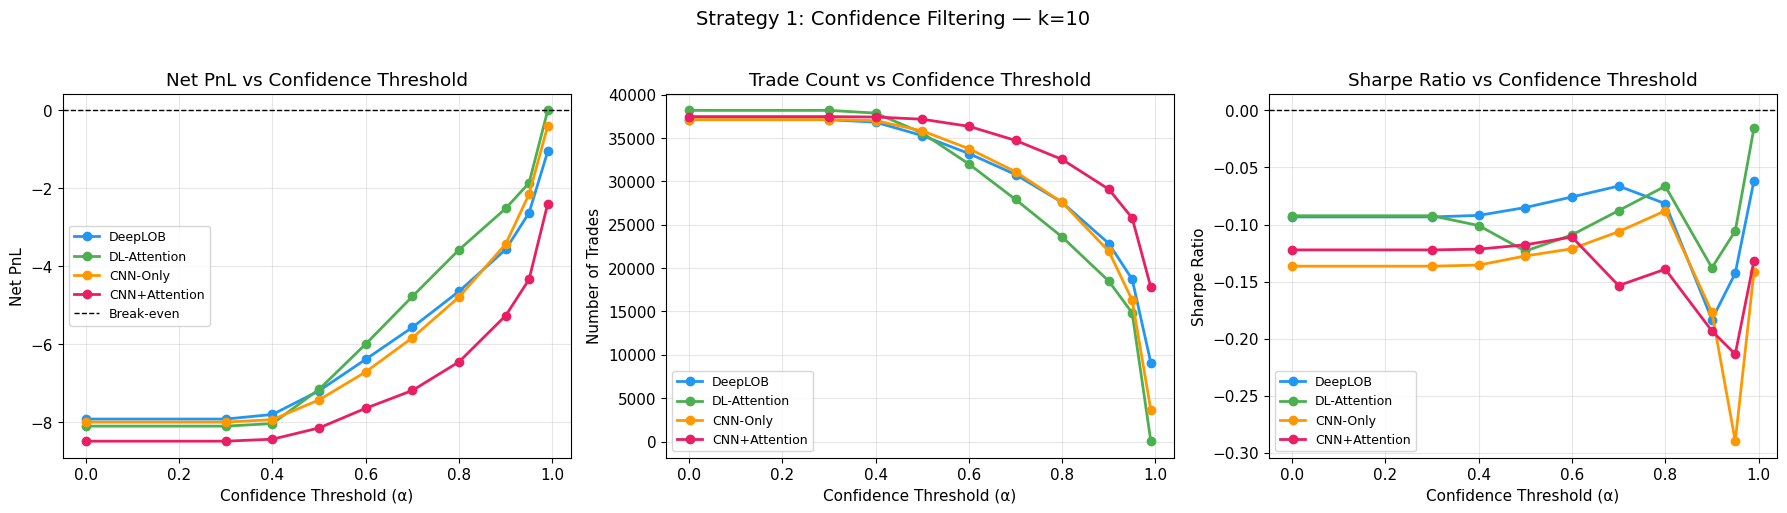

In [16]:
# Sweep confidence thresholds for all DL models at k=10
alphas = [0.0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
conf_results = {name: [] for name in DL_MODELS}

for name in DL_MODELS:
    for alpha in alphas:
        filtered_preds = apply_confidence_filter(probs_k10[name], threshold=alpha)
        bt = run_backtest(filtered_preds, mid_prices, spreads, cost_multiplier=0.5)
        conf_results[name].append({
            'alpha': alpha,
            'net_pnl': bt['metrics']['total_pnl_net'],
            'gross_pnl': bt['metrics']['total_pnl_gross'],
            'total_costs': bt['metrics']['total_costs'],
            'sharpe': bt['metrics']['sharpe_ratio'],
            'num_trades': bt['metrics']['num_trades'],
            'win_rate': bt['metrics']['win_rate'],
            'pct_flat': bt['metrics']['frac_flat'] * 100,
        })

# --- Plot 1: Net PnL vs threshold ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(DL_MODELS):
    df = pd.DataFrame(conf_results[name])
    axes[0].plot(df['alpha'], df['net_pnl'], 'o-', label=name, color=colors[i], linewidth=2)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--', label='Break-even')
axes[0].set_xlabel('Confidence Threshold (α)')
axes[0].set_ylabel('Net PnL')
axes[0].set_title('Net PnL vs Confidence Threshold')
axes[0].legend(fontsize=9)

# --- Plot 2: Trade count vs threshold ---
for i, name in enumerate(DL_MODELS):
    df = pd.DataFrame(conf_results[name])
    axes[1].plot(df['alpha'], df['num_trades'], 'o-', label=name, color=colors[i], linewidth=2)
axes[1].set_xlabel('Confidence Threshold (α)')
axes[1].set_ylabel('Number of Trades')
axes[1].set_title('Trade Count vs Confidence Threshold')
axes[1].legend(fontsize=9)

# --- Plot 3: Sharpe vs threshold ---
for i, name in enumerate(DL_MODELS):
    df = pd.DataFrame(conf_results[name])
    axes[2].plot(df['alpha'], df['sharpe'], 'o-', label=name, color=colors[i], linewidth=2)
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_xlabel('Confidence Threshold (α)')
axes[2].set_ylabel('Sharpe Ratio')
axes[2].set_title('Sharpe Ratio vs Confidence Threshold')
axes[2].legend(fontsize=9)

plt.suptitle('Strategy 1: Confidence Filtering — k=10', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Detailed table at key threshold values
print('Confidence Filtering Results — k=10')
print('=' * 90)

for name in DL_MODELS:
    print(f'\n{name}:')
    print(f'  {"α":>5} {"Net PnL":>10} {"Gross PnL":>10} {"Costs":>10} {"Trades":>8} {"Sharpe":>8} {"Win%":>6} {"Flat%":>6}')
    print(f'  {"-"*68}')
    for r in conf_results[name]:
        marker = ' ◀ BEST' if r['net_pnl'] == max(x['net_pnl'] for x in conf_results[name]) else ''
        marker += ' ✓' if r['net_pnl'] > 0 else ''
        print(f'  {r["alpha"]:>5.2f} {r["net_pnl"]:>10.4f} {r["gross_pnl"]:>10.4f} {r["total_costs"]:>10.4f} '
              f'{r["num_trades"]:>8,} {r["sharpe"]:>8.4f} {r["win_rate"]:>5.1%} {r["pct_flat"]:>5.1f}%{marker}')

# Find break-even thresholds
print('\n\nBreak-even Analysis:')
print('-' * 50)
for name in DL_MODELS:
    best = max(conf_results[name], key=lambda x: x['net_pnl'])
    profitable = [r for r in conf_results[name] if r['net_pnl'] > 0]
    if profitable:
        breakeven_alpha = min(r['alpha'] for r in profitable)
        print(f'{name:<16} Break-even at α ≈ {breakeven_alpha:.2f} | Best: α={best["alpha"]:.2f}, PnL={best["net_pnl"]:.4f}, Trades={best["num_trades"]:,}')
    else:
        print(f'{name:<16} Never profitable | Best: α={best["alpha"]:.2f}, PnL={best["net_pnl"]:.4f}, Trades={best["num_trades"]:,}')

Confidence Filtering Results — k=10

DeepLOB:
      α    Net PnL  Gross PnL      Costs   Trades   Sharpe   Win%  Flat%
  --------------------------------------------------------------------
   0.00    -7.9121     0.3251     8.2372   37,115  -0.0933  6.6%  78.0%
   0.30    -7.9121     0.3251     8.2372   37,115  -0.0933  6.6%  78.0%
   0.40    -7.7944     0.3259     8.1203   36,830  -0.0920  6.5%  78.4%
   0.50    -7.1867     0.3197     7.5063   35,281  -0.0851  5.9%  81.1%
   0.60    -6.3804     0.3097     6.6900   33,214  -0.0758  4.9%  84.4%
   0.70    -5.5621     0.3013     5.8633   30,789  -0.0663  4.3%  86.6%
   0.80    -4.6384     0.2553     4.8936   27,572  -0.0817  4.1%  88.4%
   0.90    -3.5654     0.0554     3.6208   22,836  -0.1832  4.0%  90.6%
   0.95    -2.6293     0.0345     2.6637   18,718  -0.1427  4.1%  92.5%
   0.99    -1.0538    -0.0114     1.0424    9,095  -0.0618  4.1%  96.6% ◀ BEST

DL-Attention:
      α    Net PnL  Gross PnL      Costs   Trades   Sharpe   Win%  F

## 11. Strategy 2: Holding Period Alignment

A model trained at horizon $k=10$ predicts what happens over the next 10 timesteps.
But the naive backtest re-evaluates at *every* tick — prediction at $t$ covers $[t, t+10]$
and prediction at $t+1$ covers $[t+1, t+11]$, sharing 90% of their information.

📚 **The fix**: Once a directional signal fires, **hold that position for at least
$h$ steps** before accepting a new signal. This:
1. Aligns trading frequency with the prediction horizon
2. Lets predicted moves play out before re-evaluating
3. Mechanically reduces trades by roughly $h\times$

We sweep $h \in \{1, 2, 5, 10, 20, 50, 100, 200\}$. The optimal $h$ balances two
forces: too short = excess costs from overtrading; too long = holding through reversals
as the prediction signal decays.

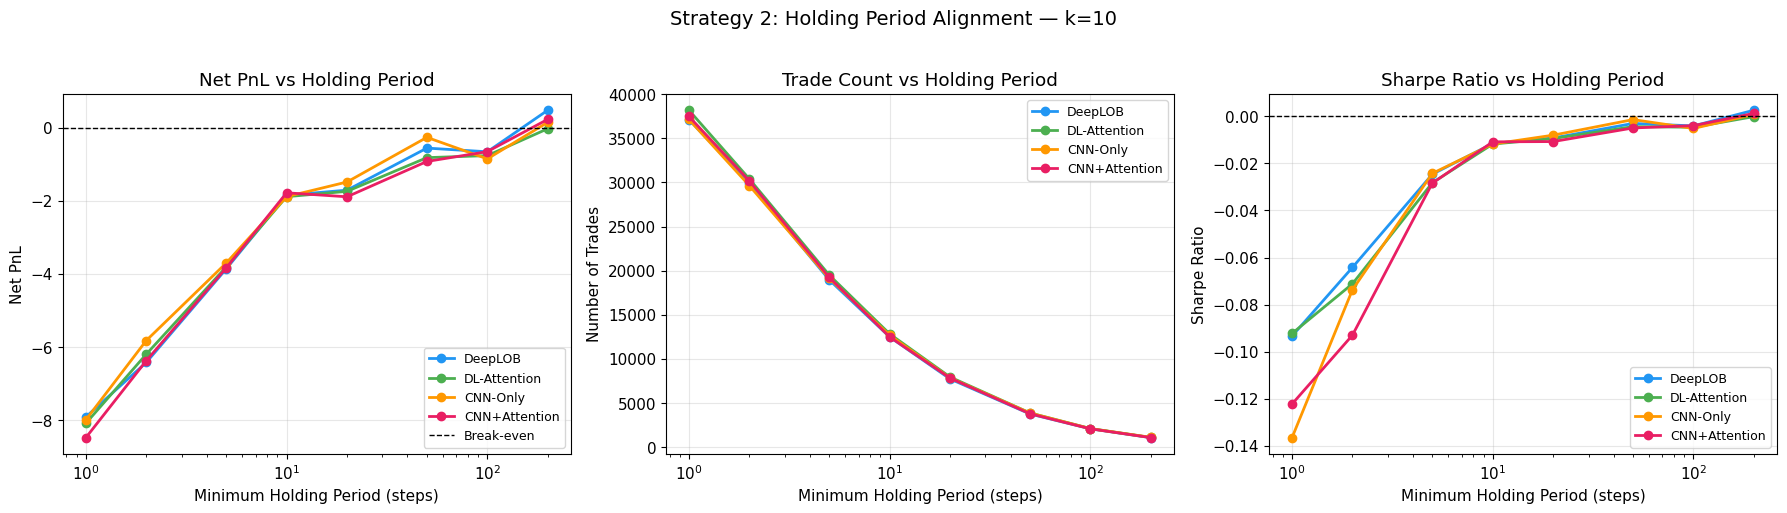

In [18]:
# Sweep holding periods for all DL models at k=10
hold_values = [1, 2, 5, 10, 20, 50, 100, 200]
hold_results = {name: [] for name in DL_MODELS}

for name in DL_MODELS:
    raw_preds = models[name]['predictions']
    for h in hold_values:
        held_preds = apply_holding_period(raw_preds, min_hold=h)
        bt = run_backtest(held_preds, mid_prices, spreads, cost_multiplier=0.5)
        hold_results[name].append({
            'hold': h,
            'net_pnl': bt['metrics']['total_pnl_net'],
            'gross_pnl': bt['metrics']['total_pnl_gross'],
            'total_costs': bt['metrics']['total_costs'],
            'sharpe': bt['metrics']['sharpe_ratio'],
            'num_trades': bt['metrics']['num_trades'],
            'win_rate': bt['metrics']['win_rate'],
            'pct_flat': bt['metrics']['frac_flat'] * 100,
        })

# --- Plot: Net PnL and Trades vs holding period ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(DL_MODELS):
    df = pd.DataFrame(hold_results[name])
    axes[0].plot(df['hold'], df['net_pnl'], 'o-', label=name, color=colors[i], linewidth=2)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--', label='Break-even')
axes[0].set_xlabel('Minimum Holding Period (steps)')
axes[0].set_ylabel('Net PnL')
axes[0].set_title('Net PnL vs Holding Period')
axes[0].set_xscale('log')
axes[0].legend(fontsize=9)

for i, name in enumerate(DL_MODELS):
    df = pd.DataFrame(hold_results[name])
    axes[1].plot(df['hold'], df['num_trades'], 'o-', label=name, color=colors[i], linewidth=2)
axes[1].set_xlabel('Minimum Holding Period (steps)')
axes[1].set_ylabel('Number of Trades')
axes[1].set_title('Trade Count vs Holding Period')
axes[1].set_xscale('log')
axes[1].legend(fontsize=9)

for i, name in enumerate(DL_MODELS):
    df = pd.DataFrame(hold_results[name])
    axes[2].plot(df['hold'], df['sharpe'], 'o-', label=name, color=colors[i], linewidth=2)
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_xlabel('Minimum Holding Period (steps)')
axes[2].set_ylabel('Sharpe Ratio')
axes[2].set_title('Sharpe Ratio vs Holding Period')
axes[2].set_xscale('log')
axes[2].legend(fontsize=9)

plt.suptitle('Strategy 2: Holding Period Alignment — k=10', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Detailed table for holding period results
print('Holding Period Results — k=10')
print('=' * 90)

for name in DL_MODELS:
    print(f'\n{name}:')
    print(f'  {"h":>5} {"Net PnL":>10} {"Gross PnL":>10} {"Costs":>10} {"Trades":>8} {"Sharpe":>8} {"Win%":>6} {"Flat%":>6}')
    print(f'  {"-"*68}')
    for r in hold_results[name]:
        marker = ' ◀ BEST' if r['net_pnl'] == max(x['net_pnl'] for x in hold_results[name]) else ''
        marker += ' ✓' if r['net_pnl'] > 0 else ''
        print(f'  {r["hold"]:>5d} {r["net_pnl"]:>10.4f} {r["gross_pnl"]:>10.4f} {r["total_costs"]:>10.4f} '
              f'{r["num_trades"]:>8,} {r["sharpe"]:>8.4f} {r["win_rate"]:>5.1%} {r["pct_flat"]:>5.1f}%{marker}')

# Break-even analysis
print('\n\nBreak-even Analysis:')
print('-' * 50)
for name in DL_MODELS:
    best = max(hold_results[name], key=lambda x: x['net_pnl'])
    profitable = [r for r in hold_results[name] if r['net_pnl'] > 0]
    if profitable:
        breakeven_h = min(r['hold'] for r in profitable)
        print(f'{name:<16} Break-even at h ≈ {breakeven_h} | Best: h={best["hold"]}, PnL={best["net_pnl"]:.4f}, Trades={best["num_trades"]:,}')
    else:
        print(f'{name:<16} Never profitable | Best: h={best["hold"]}, PnL={best["net_pnl"]:.4f}, Trades={best["num_trades"]:,}')

Holding Period Results — k=10

DeepLOB:
      h    Net PnL  Gross PnL      Costs   Trades   Sharpe   Win%  Flat%
  --------------------------------------------------------------------
      1    -7.9121     0.3251     8.2372   37,115  -0.0933  6.6%  78.0%
      2    -6.4213    -0.1244     6.2968   29,903  -0.0642  9.8%  70.8%
      5    -3.8657    -0.0245     3.8413   18,954  -0.0246 10.8%  55.2%
     10    -1.8501     0.6348     2.4849   12,488  -0.0116 10.7%  42.8%
     20    -1.7107    -0.2037     1.5070    7,729  -0.0093 10.3%  31.1%
     50    -0.5605     0.1598     0.7203    3,764  -0.0031  9.8%  17.8%
    100    -0.6611    -0.2571     0.4040    2,084  -0.0041  9.5%  10.5%
    200     0.4757     0.6829     0.2073    1,081   0.0026  9.2%   5.8% ◀ BEST ✓

DL-Attention:
      h    Net PnL  Gross PnL      Costs   Trades   Sharpe   Win%  Flat%
  --------------------------------------------------------------------
      1    -8.0866     0.5313     8.6178   38,178  -0.0922  5.4%  80.1%


## 12. Strategy 3: Combined (Confidence + Holding Period)

The two filters are **multiplicative** — confidence filtering reduces trade count by
removing low-conviction signals, and the holding period further reduces it by preventing
rapid re-entry. Combining both should produce the fewest, highest-quality trades.

We run a grid search over $(\alpha, h)$ pairs for the best-performing DL model
from the individual sweeps above.

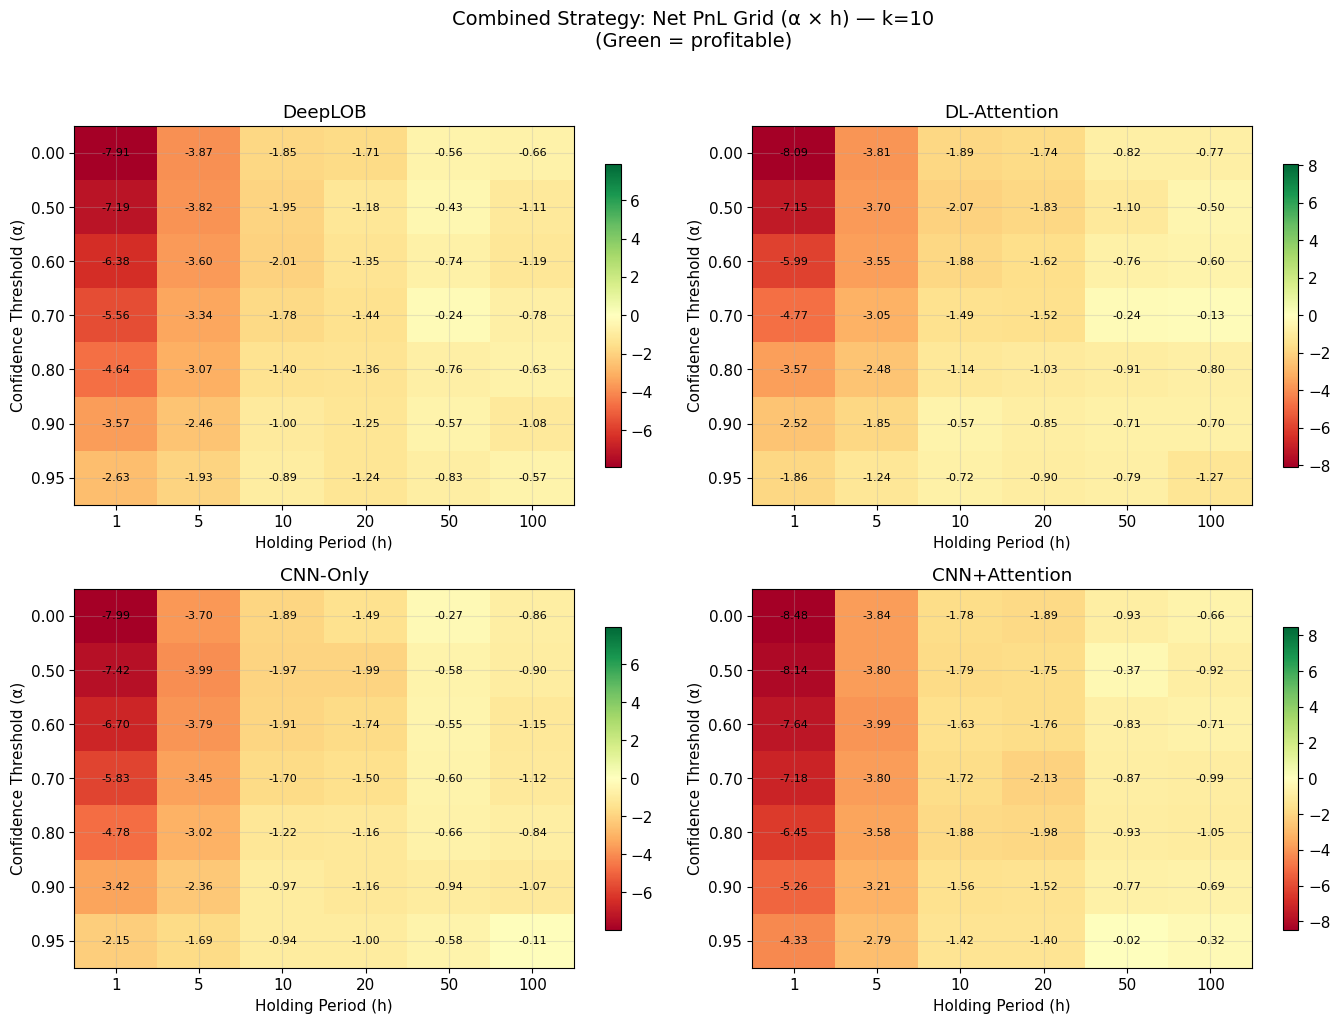

In [20]:
# Grid search: confidence threshold × holding period for ALL DL models
grid_alphas = [0.0, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
grid_holds = [1, 5, 10, 20, 50, 100]

combined_results = {}

for name in DL_MODELS:
    combined_results[name] = {}
    for alpha in grid_alphas:
        for h in grid_holds:
            # First filter by confidence, then apply holding period
            filtered_preds = apply_confidence_filter(probs_k10[name], threshold=alpha)
            held_preds = apply_holding_period(filtered_preds, min_hold=h)
            bt = run_backtest(held_preds, mid_prices, spreads, cost_multiplier=0.5)
            combined_results[name][(alpha, h)] = {
                'net_pnl': bt['metrics']['total_pnl_net'],
                'sharpe': bt['metrics']['sharpe_ratio'],
                'num_trades': bt['metrics']['num_trades'],
                'gross_pnl': bt['metrics']['total_pnl_gross'],
                'total_costs': bt['metrics']['total_costs'],
            }

# --- Heatmap: Net PnL for each model ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, name in enumerate(DL_MODELS):
    ax = axes[idx // 2, idx % 2]
    pnl_grid = np.zeros((len(grid_alphas), len(grid_holds)))
    for i, alpha in enumerate(grid_alphas):
        for j, h in enumerate(grid_holds):
            pnl_grid[i, j] = combined_results[name][(alpha, h)]['net_pnl']

    # Use diverging colormap centered at 0
    vmax = max(abs(pnl_grid.min()), abs(pnl_grid.max()))
    im = ax.imshow(pnl_grid, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(grid_holds)))
    ax.set_xticklabels(grid_holds)
    ax.set_yticks(range(len(grid_alphas)))
    ax.set_yticklabels([f'{a:.2f}' for a in grid_alphas])
    ax.set_xlabel('Holding Period (h)')
    ax.set_ylabel('Confidence Threshold (α)')
    ax.set_title(name)

    # Annotate cells
    for i in range(len(grid_alphas)):
        for j in range(len(grid_holds)):
            val = pnl_grid[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                    fontweight='bold' if val > 0 else 'normal',
                    color='black')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Combined Strategy: Net PnL Grid (α × h) — k=10\n(Green = profitable)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# Best combined strategy per model + overall best
print('Top 5 Combined Strategies (across all models):')
print('=' * 85)
print(f'{"Rank":>4} {"Model":<16} {"α":>5} {"h":>5} {"Net PnL":>10} {"Sharpe":>8} {"Trades":>8} {"Gross":>10} {"Costs":>10}')
print('-' * 85)

all_combos = []
for name in DL_MODELS:
    for (alpha, h), r in combined_results[name].items():
        all_combos.append({'model': name, 'alpha': alpha, 'hold': h, **r})

all_combos.sort(key=lambda x: x['net_pnl'], reverse=True)

for rank, r in enumerate(all_combos[:10], 1):
    marker = ' ✓' if r['net_pnl'] > 0 else ''
    print(f'{rank:>4} {r["model"]:<16} {r["alpha"]:>5.2f} {r["hold"]:>5d} {r["net_pnl"]:>10.4f} '
          f'{r["sharpe"]:>8.4f} {r["num_trades"]:>8,} {r["gross_pnl"]:>10.4f} {r["total_costs"]:>10.4f}{marker}')

# Summary
profitable_combos = [r for r in all_combos if r['net_pnl'] > 0]
print(f'\nTotal profitable combinations: {len(profitable_combos)} / {len(all_combos)}')

Top 5 Combined Strategies (across all models):
Rank Model                α     h    Net PnL   Sharpe   Trades      Gross      Costs
-------------------------------------------------------------------------------------
   1 CNN+Attention     0.95    50    -0.0229  -0.0001    3,798     0.6673     0.6902
   2 CNN-Only          0.95   100    -0.1091  -0.0006    1,822     0.1920     0.3010
   3 DL-Attention      0.70   100    -0.1278  -0.0008    2,151     0.2648     0.3926
   4 DL-Attention      0.70    50    -0.2402  -0.0016    3,868     0.4710     0.7112
   5 DeepLOB           0.70    50    -0.2438  -0.0013    3,888     0.4855     0.7294
   6 CNN-Only          0.00    50    -0.2667  -0.0014    3,872     0.4706     0.7373
   7 CNN+Attention     0.95   100    -0.3162  -0.0017    2,139     0.0750     0.3911
   8 CNN+Attention     0.50    50    -0.3735  -0.0020    3,880     0.3738     0.7474
   9 DeepLOB           0.50    50    -0.4301  -0.0023    3,828     0.2989     0.7290
  10 DL-Attention

## 13. Strategy 4: Ensemble Consensus

We have four DL models — a natural **deep ensemble** (Lakshminarayanan et al., NeurIPS 2017).
Instead of using ensemble for accuracy improvement (which often fails for LOB models per
the LOBCAST benchmark), we use it as a **trade filter**: only trade when multiple models
independently agree on the direction.

📚 **Why consensus filtering works differently from accuracy ensembling**:
When 4/4 models predict "Up," the signal is far more reliable than 2/4. The purpose
isn't to improve average accuracy — it's to identify the subset of timesteps where
*all independent evidence points the same way*. These are exactly the trades worth paying
the spread for.

We test:
1. **Probability averaging** — average softmax vectors, then threshold
2. **Vote consensus** — require $N$ of 4 models to agree (N ∈ {2, 3, 4})
3. **Full pipeline** — consensus + confidence threshold + holding period

In [22]:
# --- Ensemble strategies ---
prob_list = [probs_k10[name] for name in DL_MODELS]

# 1. Probability averaging with confidence sweep
print('Ensemble via Probability Averaging:')
print('=' * 80)
print(f'  {"α":>5} {"Net PnL":>10} {"Gross PnL":>10} {"Costs":>10} {"Trades":>8} {"Sharpe":>8} {"Win%":>6}')
print(f'  {"-"*62}')

ens_avg_results = []
for alpha in [0.0, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    preds, avg_probs = ensemble_predictions(prob_list, confidence_threshold=alpha if alpha > 0 else None)
    bt = run_backtest(preds, mid_prices, spreads, cost_multiplier=0.5)
    r = {'alpha': alpha, **bt['metrics']}
    ens_avg_results.append(r)
    marker = ' ✓' if r['total_pnl_net'] > 0 else ''
    print(f'  {alpha:>5.2f} {r["total_pnl_net"]:>10.4f} {r["total_pnl_gross"]:>10.4f} {r["total_costs"]:>10.4f} '
          f'{r["num_trades"]:>8,} {r["sharpe_ratio"]:>8.4f} {r["win_rate"]:>5.1%}{marker}')

# 2. Vote consensus (require N/4 models to agree)
print(f'\n\nEnsemble via Vote Consensus:')
print('=' * 80)
print(f'  {"Min Agree":>9} {"Net PnL":>10} {"Gross PnL":>10} {"Costs":>10} {"Trades":>8} {"Sharpe":>8} {"Win%":>6}')
print(f'  {"-"*66}')

ens_vote_results = []
for min_agree in [1, 2, 3, 4]:
    preds, avg_probs = ensemble_predictions(prob_list, min_agreement=min_agree)
    bt = run_backtest(preds, mid_prices, spreads, cost_multiplier=0.5)
    r = {'min_agreement': min_agree, **bt['metrics']}
    ens_vote_results.append(r)
    marker = ' ✓' if r['total_pnl_net'] > 0 else ''
    print(f'  {min_agree:>5d}/4   {r["total_pnl_net"]:>10.4f} {r["total_pnl_gross"]:>10.4f} {r["total_costs"]:>10.4f} '
          f'{r["num_trades"]:>8,} {r["sharpe_ratio"]:>8.4f} {r["win_rate"]:>5.1%}{marker}')

Ensemble via Probability Averaging:
      α    Net PnL  Gross PnL      Costs   Trades   Sharpe   Win%
  --------------------------------------------------------------
   0.00    -8.2770     0.2011     8.4780   37,483  -0.1196  5.9%
   0.30    -8.2770     0.2011     8.4780   37,483  -0.1196  5.9%
   0.50    -7.5013     0.1926     7.6939   35,944  -0.1091  4.9%
   0.60    -6.4386     0.2801     6.7187   33,311  -0.1117  4.2%
   0.70    -5.3501     0.2726     5.6226   29,840  -0.0936  4.0%
   0.80    -4.3426     0.0727     4.4153   25,664  -0.2130  4.0%
   0.90    -2.8934     0.0429     2.9362   19,959  -0.1548  4.2%
   0.95    -1.9765     0.0214     1.9979   15,497  -0.1115  4.3%
   0.99    -0.3445     0.0115     0.3560    3,276  -0.1345  4.5%


Ensemble via Vote Consensus:
  Min Agree    Net PnL  Gross PnL      Costs   Trades   Sharpe   Win%
  ------------------------------------------------------------------
      1/4      -8.2767     0.2010     8.4777   37,483  -0.1196  5.9%
      2/4

In [23]:
# 3. Full pipeline: ensemble + confidence + holding period
# Grid search the most promising ensemble configurations
print('Full Pipeline: Ensemble Avg + Confidence + Holding Period')
print('=' * 95)
print(f'  {"α":>5} {"h":>5} {"Agree":>5} {"Net PnL":>10} {"Gross":>10} {"Costs":>10} {"Trades":>8} {"Sharpe":>8}')
print(f'  {"-"*70}')

full_pipeline_results = []
pipeline_alphas = [0.0, 0.5, 0.7, 0.8, 0.9, 0.95]
pipeline_holds = [1, 10, 20, 50, 100]
pipeline_agreements = [1, 3, 4]

for min_agree in pipeline_agreements:
    for alpha in pipeline_alphas:
        for h in pipeline_holds:
            # Ensemble with consensus + confidence
            preds, avg_probs = ensemble_predictions(
                prob_list,
                min_agreement=min_agree,
                confidence_threshold=alpha if alpha > 0 else None,
            )
            # Apply holding period
            held_preds = apply_holding_period(preds, min_hold=h)
            bt = run_backtest(held_preds, mid_prices, spreads, cost_multiplier=0.5)
            full_pipeline_results.append({
                'alpha': alpha, 'hold': h, 'min_agreement': min_agree,
                **bt['metrics'],
            })

# Sort by net PnL and show top results
full_pipeline_results.sort(key=lambda x: x['total_pnl_net'], reverse=True)

for r in full_pipeline_results[:15]:
    marker = ' ✓' if r['total_pnl_net'] > 0 else ''
    print(f'  {r["alpha"]:>5.2f} {r["hold"]:>5d} {r["min_agreement"]:>3d}/4 {r["total_pnl_net"]:>10.4f} '
          f'{r["total_pnl_gross"]:>10.4f} {r["total_costs"]:>10.4f} {r["num_trades"]:>8,} {r["sharpe_ratio"]:>8.4f}{marker}')

profitable = [r for r in full_pipeline_results if r['total_pnl_net'] > 0]
print(f'\nProfitable configurations: {len(profitable)} / {len(full_pipeline_results)}')

Full Pipeline: Ensemble Avg + Confidence + Holding Period
      α     h Agree    Net PnL      Gross      Costs   Trades   Sharpe
  ----------------------------------------------------------------------


   0.70   100   1/4    -0.3264     0.0762     0.4026    2,168  -0.0020
   0.70   100   3/4    -0.3264     0.0762     0.4026    2,168  -0.0020
   0.00    50   1/4    -0.5174     0.2069     0.7243    3,851  -0.0028
   0.50    50   4/4    -0.6145     0.1042     0.7187    3,860  -0.0033
   0.00    50   4/4    -0.6161     0.1044     0.7205    3,864  -0.0033
   0.50   100   3/4    -0.6231    -0.2109     0.4122    2,170  -0.0039
   0.95    10   1/4    -0.6274     0.3206     0.9480    7,308  -0.0043
   0.95    10   3/4    -0.6274     0.3206     0.9480    7,308  -0.0043
   0.95    10   4/4    -0.6274     0.3206     0.9480    7,308  -0.0043
   0.80   100   4/4    -0.6855    -0.2953     0.3903    2,151  -0.0042
   0.80   100   1/4    -0.6872    -0.2974     0.3898    2,147  -0.0042
   0.80   100   3/4    -0.6872    -0.2974     0.3898    2,147  -0.0042
   0.00   100   4/4    -0.6894    -0.2874     0.4020    2,176  -0.0042
   0.50   100   4/4    -0.6894    -0.2866     0.4028    2,177  -0.0042
   0.9

## 14. Baseline Models: Confidence Filtering & Holding Period

The advanced strategies above only tested the 4 DL models. Now that we have softmax
probabilities for the baselines too, let's see how **XGBoost** and **Logistic Regression**
respond to the same filters.

📚 **Why this matters**: LogReg already barely trades in the naive backtest (97.2% flat,
only 5,751 trades) — it naturally "filters" by being conservative. XGBoost trades more
(28,517 trades) but less than the DL models (~37K). Do the filters help these models too,
or is there diminishing returns when the model is already conservative?

In [24]:
# Load baseline probabilities at k=10
BASELINE_MODELS = ['XGBoost', 'LogReg']
baseline_prob_paths = {
    'XGBoost': 'experiments/baselines/xgboost_k{h}_probabilities.npy',
    'LogReg':  'experiments/baselines/logistic_regression_k{h}_probabilities.npy',
}

baseline_probs_k10 = {}
for name, path_template in baseline_prob_paths.items():
    path = PROJECT_ROOT / path_template.format(h=10)
    baseline_probs_k10[name] = np.load(path)

print('Baseline probability vectors (k=10):')
print(f'{"Model":<12} {"Shape":>16} {"Max prob (mean)":>16} {"Max prob (std)":>16}')
print('-' * 64)
for name, p in baseline_probs_k10.items():
    print(f'{name:<12} {str(p.shape):>16} {p.max(axis=1).mean():>16.4f} {p.max(axis=1).std():>16.4f}')

# --- Confidence filtering sweep for baselines ---
print('\n\nConfidence Filtering — Baselines at k=10:')
print('=' * 90)
baseline_conf_results = {}

for name in BASELINE_MODELS:
    baseline_conf_results[name] = []
    print(f'\n{name}:')
    print(f'  {"α":>5} {"Net PnL":>10} {"Gross PnL":>10} {"Costs":>10} {"Trades":>8} {"Sharpe":>8} {"Win%":>6} {"Flat%":>6}')
    print(f'  {"-"*68}')
    for alpha in alphas:
        filtered_preds = apply_confidence_filter(baseline_probs_k10[name], threshold=alpha)
        bt = run_backtest(filtered_preds, mid_prices, spreads, cost_multiplier=0.5)
        r = {'alpha': alpha, 'net_pnl': bt['metrics']['total_pnl_net'],
             'gross_pnl': bt['metrics']['total_pnl_gross'],
             'total_costs': bt['metrics']['total_costs'],
             'sharpe': bt['metrics']['sharpe_ratio'],
             'num_trades': bt['metrics']['num_trades'],
             'win_rate': bt['metrics']['win_rate'],
             'pct_flat': bt['metrics']['frac_flat'] * 100}
        baseline_conf_results[name].append(r)
        marker = ' ◀ BEST' if r['net_pnl'] == max(x['net_pnl'] for x in baseline_conf_results[name]) else ''
        marker += ' ✓' if r['net_pnl'] > 0 else ''
        print(f'  {alpha:>5.2f} {r["net_pnl"]:>10.4f} {r["gross_pnl"]:>10.4f} {r["total_costs"]:>10.4f} '
              f'{r["num_trades"]:>8,} {r["sharpe"]:>8.4f} {r["win_rate"]:>5.1%} {r["pct_flat"]:>5.1f}%{marker}')

Baseline probability vectors (k=10):
Model                   Shape  Max prob (mean)   Max prob (std)
----------------------------------------------------------------
XGBoost           (139488, 3)           0.7186           0.1286
LogReg            (139488, 3)           0.6369           0.0770


Confidence Filtering — Baselines at k=10:

XGBoost:
      α    Net PnL  Gross PnL      Costs   Trades   Sharpe   Win%  Flat%
  --------------------------------------------------------------------
   0.00    -5.7147     0.2267     5.9414   28,517  -0.1036  6.1%  85.6% ◀ BEST
   0.30    -5.7147     0.2267     5.9414   28,517  -0.1036  6.1%  85.6% ◀ BEST
   0.40    -5.5132     0.2278     5.7410   28,128  -0.1003  5.8%  86.3% ◀ BEST
   0.50    -4.2617     0.2066     4.4683   23,700  -0.0784  4.7%  89.6% ◀ BEST
   0.60    -3.1517     0.0412     3.1929   18,333  -0.1609  4.3%  92.4% ◀ BEST
   0.70    -2.1323     0.0240     2.1563   13,564  -0.1161  4.1%  94.6% ◀ BEST
   0.80    -1.2427     0.0084     

Holding Period — Baselines at k=10:

XGBoost:
      h    Net PnL  Gross PnL      Costs   Trades   Sharpe   Win%  Flat%
  --------------------------------------------------------------------
      1    -5.7147     0.2267     5.9414   28,517  -0.1036  6.1%  85.6% ◀ BEST
      2    -4.3652     0.2146     4.5798   23,383  -0.0800 10.2%  79.1% ◀ BEST
      5    -3.0805    -0.0528     3.0277   16,093  -0.0305 11.2%  65.2% ◀ BEST
     10    -1.4423     0.6312     2.0735   11,236  -0.0090 11.0%  52.7% ◀ BEST
     20    -1.3946    -0.0582     1.3364    7,283  -0.0077 10.7%  40.0% ◀ BEST
     50    -0.1722     0.5047     0.6770    3,721  -0.0011 10.0%  23.8% ◀ BEST
    100    -1.0267    -0.6483     0.3784    2,078  -0.0055  9.7%  15.8%
    200    -0.4415    -0.2310     0.2106    1,139  -0.0027  9.4%   8.7%

LogReg:
      h    Net PnL  Gross PnL      Costs   Trades   Sharpe   Win%  Flat%
  --------------------------------------------------------------------
      1    -0.7918     0.0280     0.819

     10     0.0789     0.5242     0.4452    3,688   0.0006 10.6%  85.8% ◀ BEST ✓


     20     0.1398     0.4696     0.3298    2,793   0.0011 10.2%  78.8% ◀ BEST ✓
     50     0.3642     0.5659     0.2017    1,728   0.0026  9.6%  67.4% ◀ BEST ✓
    100     0.6144     0.7420     0.1276    1,085   0.0038  9.4%  59.5% ◀ BEST ✓
    200     0.4935     0.5701     0.0765      652   0.0036  9.1%  51.5% ✓


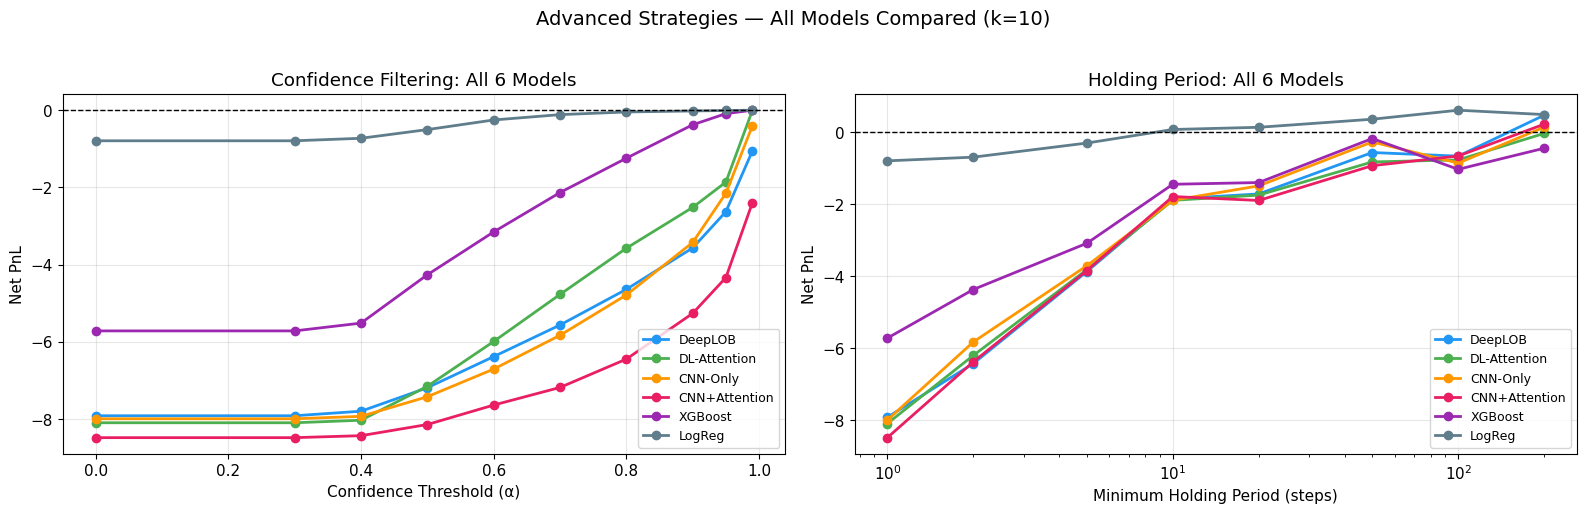

In [25]:
# --- Holding period sweep for baselines ---
print('Holding Period — Baselines at k=10:')
print('=' * 90)
baseline_hold_results = {}

for name in BASELINE_MODELS:
    baseline_hold_results[name] = []
    raw_preds = models[name]['predictions']
    print(f'\n{name}:')
    print(f'  {"h":>5} {"Net PnL":>10} {"Gross PnL":>10} {"Costs":>10} {"Trades":>8} {"Sharpe":>8} {"Win%":>6} {"Flat%":>6}')
    print(f'  {"-"*68}')
    for h in hold_values:
        held_preds = apply_holding_period(raw_preds, min_hold=h)
        bt = run_backtest(held_preds, mid_prices, spreads, cost_multiplier=0.5)
        r = {'hold': h, 'net_pnl': bt['metrics']['total_pnl_net'],
             'gross_pnl': bt['metrics']['total_pnl_gross'],
             'total_costs': bt['metrics']['total_costs'],
             'sharpe': bt['metrics']['sharpe_ratio'],
             'num_trades': bt['metrics']['num_trades'],
             'win_rate': bt['metrics']['win_rate'],
             'pct_flat': bt['metrics']['frac_flat'] * 100}
        baseline_hold_results[name].append(r)
        marker = ' ◀ BEST' if r['net_pnl'] == max(x['net_pnl'] for x in baseline_hold_results[name]) else ''
        marker += ' ✓' if r['net_pnl'] > 0 else ''
        print(f'  {h:>5d} {r["net_pnl"]:>10.4f} {r["gross_pnl"]:>10.4f} {r["total_costs"]:>10.4f} '
              f'{r["num_trades"]:>8,} {r["sharpe"]:>8.4f} {r["win_rate"]:>5.1%} {r["pct_flat"]:>5.1f}%{marker}')

# --- Combined plot: all 6 models confidence filtering ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

all_conf = {**conf_results, **baseline_conf_results}
all_colors = {'DeepLOB': '#2196F3', 'DL-Attention': '#4CAF50', 'CNN-Only': '#FF9800',
              'CNN+Attention': '#E91E63', 'XGBoost': '#9C27B0', 'LogReg': '#607D8B'}

for name in [*DL_MODELS, *BASELINE_MODELS]:
    df = pd.DataFrame(all_conf[name])
    axes[0].plot(df['alpha'], df['net_pnl'], 'o-', label=name, color=all_colors[name], linewidth=2)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel('Confidence Threshold (α)')
axes[0].set_ylabel('Net PnL')
axes[0].set_title('Confidence Filtering: All 6 Models')
axes[0].legend(fontsize=9)

all_hold = {**hold_results, **baseline_hold_results}
for name in [*DL_MODELS, *BASELINE_MODELS]:
    df = pd.DataFrame(all_hold[name])
    axes[1].plot(df['hold'], df['net_pnl'], 'o-', label=name, color=all_colors[name], linewidth=2)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Minimum Holding Period (steps)')
axes[1].set_ylabel('Net PnL')
axes[1].set_title('Holding Period: All 6 Models')
axes[1].set_xscale('log')
axes[1].legend(fontsize=9)

plt.suptitle('Advanced Strategies — All Models Compared (k=10)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 15. Strategy 5: Temperature Scaling & Recalibrated Confidence Filtering

**Temperature scaling** (Guo et al., ICML 2017) addresses a fundamental problem with neural
network confidence: modern deep networks are **systematically overconfident**. A model that
outputs max(softmax) = 0.90 might only be correct 70% of the time. This means our confidence
threshold α from Section 10 isn't filtering on *actual* confidence — it's filtering on
*uncalibrated* scores.

📚 **How temperature scaling works:**
- Learn a single parameter T > 0 on the validation set by minimizing negative log-likelihood
- Apply calibrated softmax: `P_calibrated = softmax(logits / T)`
- If T > 1: model was overconfident → probabilities become "softer" (more spread out)
- If T < 1: model was underconfident → probabilities become "sharper"
- T = 1: model was already well-calibrated (no change needed)

The key insight: with properly calibrated probabilities, the confidence threshold α becomes
*meaningful* — α = 0.7 actually means "the model is 70% likely to be correct."

In [26]:
import torch.nn.functional as F
from scipy.optimize import minimize_scalar

# --- Step 1: Load validation logits and labels ---
val_y = torch.load(PROJECT_ROOT / 'data/processed/val_y.pt', weights_only=True)
val_labels = val_y[:, 0].numpy()  # k=10 is index 0

# Load validation logits for each DL model
val_data = {}
dl_exp_dirs = {
    'DeepLOB': PROJECT_ROOT / 'experiments/k10',
    'DL-Attention': PROJECT_ROOT / 'experiments/extension/k10',
    'CNN-Only': PROJECT_ROOT / 'experiments/ablation/cnn_only/k10',
    'CNN+Attention': PROJECT_ROOT / 'experiments/ablation/cnn_attention/k10',
}

for name, exp_dir in dl_exp_dirs.items():
    vp = torch.load(exp_dir / 'val_probabilities.pt', weights_only=False)
    val_data[name] = {
        'logits': vp['logits'].numpy(),
        'probabilities': vp['probabilities'].numpy(),
    }

# --- Step 2: Learn temperature T for each model ---
def nll_with_temperature(T, logits, labels):
    """Negative log-likelihood with temperature scaling."""
    # softmax(logits / T)
    scaled = logits / T
    # Numerically stable log-softmax
    log_probs = scaled - np.log(np.exp(scaled).sum(axis=1, keepdims=True))
    # NLL = -mean(log_prob of correct class)
    return -log_probs[np.arange(len(labels)), labels].mean()

print('Temperature Scaling — Learning T on Validation Set')
print('=' * 70)
print(f'{"Model":<20} {"T*":>6} {"NLL (before)":>14} {"NLL (after)":>14} {"Change":>10}')
print('-' * 70)

temperatures = {}
for name in DL_MODELS:
    logits = val_data[name]['logits']

    # NLL before (T=1)
    nll_before = nll_with_temperature(1.0, logits, val_labels)

    # Optimize T
    result = minimize_scalar(
        lambda T: nll_with_temperature(T, logits, val_labels),
        bounds=(0.1, 10.0),
        method='bounded',
    )
    T_star = result.x
    nll_after = result.fun
    temperatures[name] = T_star

    change = ((nll_after - nll_before) / nll_before) * 100
    print(f'{name:<20} {T_star:>6.3f} {nll_before:>14.4f} {nll_after:>14.4f} {change:>9.1f}%')

print()
for name, T in temperatures.items():
    if T > 1:
        print(f'  {name}: T={T:.3f} > 1 → model is OVERCONFIDENT (softmax too sharp)')
    elif T < 1:
        print(f'  {name}: T={T:.3f} < 1 → model is UNDERCONFIDENT (softmax too flat)')
    else:
        print(f'  {name}: T={T:.3f} ≈ 1 → model is well-calibrated')

Temperature Scaling — Learning T on Validation Set
Model                    T*   NLL (before)    NLL (after)     Change
----------------------------------------------------------------------
DeepLOB               1.315         0.6729         0.6528      -3.0%
DL-Attention          1.195         0.6728         0.6658      -1.0%
CNN-Only              1.280         0.6362         0.6192      -2.7%
CNN+Attention         1.335         0.6291         0.6064      -3.6%

  DeepLOB: T=1.315 > 1 → model is OVERCONFIDENT (softmax too sharp)
  DL-Attention: T=1.195 > 1 → model is OVERCONFIDENT (softmax too sharp)
  CNN-Only: T=1.280 > 1 → model is OVERCONFIDENT (softmax too sharp)
  CNN+Attention: T=1.335 > 1 → model is OVERCONFIDENT (softmax too sharp)


In [27]:
# --- Step 3: Apply temperature scaling to test probabilities ---
# Recover test logits from saved probabilities: log(softmax(z)) = z - logsumexp(z)
# Since softmax is shift-invariant, log(probs) works as logits for re-scaling.

calibrated_probs = {}
for name in DL_MODELS:
    test_probs = probs_k10[name]
    T = temperatures[name]
    # Recover logits (up to constant shift, which doesn't affect softmax)
    test_logits = np.log(test_probs + 1e-10)  # add epsilon to avoid log(0)
    # Apply temperature scaling
    scaled_logits = test_logits / T
    # Recompute softmax
    exp_scaled = np.exp(scaled_logits - scaled_logits.max(axis=1, keepdims=True))
    calibrated = exp_scaled / exp_scaled.sum(axis=1, keepdims=True)
    calibrated_probs[name] = calibrated

# Show how calibration changes the probability distribution
print('Effect of Temperature Scaling on Test Set Confidence')
print('=' * 75)
print(f'{"Model":<20} {"T":>5} {"Mean max(p) raw":>16} {"Mean max(p) cal":>16} {"Δ":>8}')
print('-' * 75)
for name in DL_MODELS:
    raw_mean = probs_k10[name].max(axis=1).mean()
    cal_mean = calibrated_probs[name].max(axis=1).mean()
    print(f'{name:<20} {temperatures[name]:>5.2f} {raw_mean:>16.4f} {cal_mean:>16.4f} {cal_mean-raw_mean:>+8.4f}')

# --- Step 4: Re-run confidence filtering with calibrated probabilities ---
alphas = [0.0, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]

print('\n\nCalibrated Confidence Filtering — α Sweep (k=10)')
print('=' * 90)

cal_conf_results = {}
for name in DL_MODELS:
    results = []
    for alpha in alphas:
        preds = apply_confidence_filter(calibrated_probs[name], threshold=alpha)
        bt = run_backtest(preds, mid_prices, spreads)
        m = bt['metrics']
        results.append({
            'alpha': alpha,
            'net_pnl': m['total_pnl_net'],
            'sharpe': m['sharpe_ratio'],
            'num_trades': m['num_trades'],
            'costs': m['total_costs'],
        })
    cal_conf_results[name] = results

# Compare raw vs calibrated at key thresholds
print(f'\n{"Model":<18} {"α":>5} {"Raw Net PnL":>12} {"Cal Net PnL":>12} {"Raw Trades":>11} {"Cal Trades":>11} {"Better?":>8}')
print('-' * 90)

improvement_count = 0
for name in DL_MODELS:
    for alpha in [0.5, 0.7, 0.9]:
        raw_r = next(r for r in conf_results[name] if r['alpha'] == alpha)
        cal_r = next(r for r in cal_conf_results[name] if r['alpha'] == alpha)
        better = '✓' if cal_r['net_pnl'] > raw_r['net_pnl'] else ''
        if cal_r['net_pnl'] > raw_r['net_pnl']:
            improvement_count += 1
        print(f'{name:<18} {alpha:>5.2f} {raw_r["net_pnl"]:>12.4f} {cal_r["net_pnl"]:>12.4f} '
              f'{raw_r["num_trades"]:>11,} {cal_r["num_trades"]:>11,} {better:>8}')
    print()

print(f'Calibration improved {improvement_count}/{len(DL_MODELS)*3} configurations')

# --- Step 5: Calibrated + Holding Period (best combo) ---
print('\n\nCalibrated + Holding Period — Best Configurations')
print('=' * 90)

cal_hold_results = {}
best_cal_pnl = -999
best_cal_config = None

holds_to_test = [10, 20, 50, 100, 200]
for name in DL_MODELS:
    for alpha in [0.0, 0.5, 0.7, 0.9]:
        for h in holds_to_test:
            preds = apply_confidence_filter(calibrated_probs[name], threshold=alpha)
            preds = apply_holding_period(preds, min_hold=h)
            bt = run_backtest(preds, mid_prices, spreads)
            m = bt['metrics']
            if m['total_pnl_net'] > best_cal_pnl:
                best_cal_pnl = m['total_pnl_net']
                best_cal_config = {
                    'model': name, 'alpha': alpha, 'hold': h,
                    'net_pnl': m['total_pnl_net'], 'sharpe': m['sharpe_ratio'],
                    'trades': m['num_trades'], 'costs': m['total_costs'],
                }
            key = (name, alpha, h)
            cal_hold_results[key] = m['total_pnl_net']

# Show profitable calibrated configs
print(f'\n{"Model":<18} {"α":>5} {"h":>5} {"Net PnL":>10} {"Sharpe":>8} {"Trades":>8}')
print('-' * 65)
profitable_configs = []
for name in DL_MODELS:
    for alpha in [0.0, 0.5, 0.7, 0.9]:
        for h in holds_to_test:
            key = (name, alpha, h)
            pnl = cal_hold_results[key]
            if pnl > 0:
                preds = apply_confidence_filter(calibrated_probs[name], threshold=alpha)
                preds = apply_holding_period(preds, min_hold=h)
                bt = run_backtest(preds, mid_prices, spreads)
                m = bt['metrics']
                profitable_configs.append({
                    'model': name, 'alpha': alpha, 'hold': h,
                    'net_pnl': pnl, 'sharpe': m['sharpe_ratio'], 'trades': m['num_trades'],
                })
                print(f'{name:<18} {alpha:>5.2f} {h:>5} {pnl:>10.4f} {m["sharpe_ratio"]:>8.4f} {m["num_trades"]:>8,}')

if not profitable_configs:
    print('  (no profitable calibrated DL configurations found)')
else:
    print(f'\n  {len(profitable_configs)} profitable calibrated configurations found')

if best_cal_config:
    print(f'\n  Best calibrated config: {best_cal_config["model"]}, '
          f'α={best_cal_config["alpha"]}, h={best_cal_config["hold"]} '
          f'→ PnL={best_cal_config["net_pnl"]:.4f}')

Effect of Temperature Scaling on Test Set Confidence
Model                    T  Mean max(p) raw  Mean max(p) cal        Δ
---------------------------------------------------------------------------
DeepLOB               1.31           0.8266           0.7682  -0.0584
DL-Attention          1.19           0.8181           0.7789  -0.0392
CNN-Only              1.28           0.8511           0.7967  -0.0544
CNN+Attention         1.33           0.8617           0.8042  -0.0575


Calibrated Confidence Filtering — α Sweep (k=10)



Model                  α  Raw Net PnL  Cal Net PnL  Raw Trades  Cal Trades  Better?
------------------------------------------------------------------------------------------
DeepLOB             0.50      -7.1867      -6.8138      35,281      34,378        ✓
DeepLOB             0.70      -5.5621      -4.7910      30,789      28,145        ✓
DeepLOB             0.90      -3.5654      -2.4973      22,836      18,059        ✓

DL-Attention        0.50      -7.1496      -6.7939      35,584      34,602        ✓
DL-Attention        0.70      -4.7699      -4.0678      27,917      25,459        ✓
DL-Attention        0.90      -2.5160      -2.0164      18,494      15,804        ✓

CNN-Only            0.50      -7.4197      -7.1331      35,825      35,101        ✓
CNN-Only            0.70      -5.8286      -5.0524      31,115      28,527        ✓
CNN-Only            0.90      -3.4247      -2.1075      21,942      16,056        ✓

CNN+Attention       0.50      -8.1393      -7.9364      37,170   


Model                  α     h    Net PnL   Sharpe   Trades
-----------------------------------------------------------------
DeepLOB             0.00   200     0.4757   0.0026    1,081
DeepLOB             0.90   200     0.3920   0.0022    1,098
CNN-Only            0.00   200     0.1447   0.0008    1,117
CNN-Only            0.50   200     0.1741   0.0009    1,128
CNN+Attention       0.00   200     0.2258   0.0012    1,084
CNN+Attention       0.70   200     0.3257   0.0017    1,158
CNN+Attention       0.90   200     0.2092   0.0011    1,168

  7 profitable calibrated configurations found

  Best calibrated config: DeepLOB, α=0.0, h=200 → PnL=0.4757


## 16. Strategy 6: Cross-Horizon Consensus

A model trained at **k=10** predicts what happens in the next 10 timesteps (short-term).
A model trained at **k=100** predicts over 100 timesteps (longer-term trend). When both
agree on direction, the trade is supported by both an **immediate signal** and a
**sustained trend** — a much stronger basis for action.

📚 **Why this might work:**
- Short-horizon models capture immediate microstructure (order imbalance, spread dynamics)
- Long-horizon models capture broader directional trends
- Agreement between timescales filters out noise where short-term and long-term conflict
- Hronec & Tobek (2021) found that multi-horizon agreement achieved the highest Sharpe
  ratios in equity returns, with Sharpe improving at longer horizons because consensus
  requirements reduce turnover

We have all 30 probability files (6 models × 5 horizons), so this is fully post-hoc.

In [28]:
# Load test probabilities for all horizons (DL models only)
HORIZONS = [10, 20, 30, 50, 100]

# Structure: multi_horizon_probs[model_name][horizon] = (N, 3) array
multi_horizon_probs = {}
dl_path_templates = {
    'DeepLOB': 'experiments/k{h}',
    'DL-Attention': 'experiments/extension/k{h}',
    'CNN-Only': 'experiments/ablation/cnn_only/k{h}',
    'CNN+Attention': 'experiments/ablation/cnn_attention/k{h}',
}

for name, template in dl_path_templates.items():
    multi_horizon_probs[name] = {}
    for h in HORIZONS:
        path = PROJECT_ROOT / template.format(h=h) / 'test_probabilities.pt'
        probs = torch.load(path, weights_only=True).numpy()
        multi_horizon_probs[name][h] = probs

print(f'Loaded probabilities: {len(multi_horizon_probs)} models × {len(HORIZONS)} horizons')
print(f'Test samples per horizon: {multi_horizon_probs["DeepLOB"][10].shape[0]}')

# --- Cross-horizon consensus: require k=10 + k_other to agree ---
print('\n\nCross-Horizon Consensus — Same Model, Different Horizons (k=10 base)')
print('=' * 90)
print(f'{"Model":<18} {"Gate k":>7} {"Net PnL":>10} {"Sharpe":>8} {"Trades":>8} {"Trade Δ":>10}')
print('-' * 90)

cross_hz_results = {}
for name in DL_MODELS:
    base_preds = multi_horizon_probs[name][10].argmax(axis=1)  # k=10 predictions
    base_bt = run_backtest(base_preds, mid_prices, spreads)
    base_trades = base_bt['metrics']['num_trades']

    for gate_k in [20, 30, 50, 100]:
        gate_preds = multi_horizon_probs[name][gate_k].argmax(axis=1)

        # Only trade when k=10 and gate_k agree on directional prediction
        # If they disagree, map to Stationary (1)
        filtered = base_preds.copy()
        disagree = base_preds != gate_preds
        filtered[disagree] = 1  # Stationary when horizons disagree

        bt = run_backtest(filtered, mid_prices, spreads)
        m = bt['metrics']
        trade_reduction = f'{(1 - m["num_trades"]/base_trades)*100:.0f}%' if base_trades > 0 else 'N/A'

        key = (name, gate_k)
        cross_hz_results[key] = {
            'net_pnl': m['total_pnl_net'],
            'sharpe': m['sharpe_ratio'],
            'trades': m['num_trades'],
            'costs': m['total_costs'],
        }

        marker = ' ✓' if m['total_pnl_net'] > 0 else ''
        print(f'{name:<18} {gate_k:>7} {m["total_pnl_net"]:>10.4f} {m["sharpe_ratio"]:>8.4f} '
              f'{m["num_trades"]:>8,} {"-" + trade_reduction:>10}{marker}')
    print()

Loaded probabilities: 4 models × 5 horizons
Test samples per horizon: 139488


Cross-Horizon Consensus — Same Model, Different Horizons (k=10 base)
Model               Gate k    Net PnL   Sharpe   Trades    Trade Δ
------------------------------------------------------------------------------------------
DeepLOB                 20    -6.7195  -0.0982   33,322       -10%
DeepLOB                 30    -5.8727  -0.0700   31,932       -14%
DeepLOB                 50    -4.9609  -0.0973   27,755       -25%
DeepLOB                100    -4.5084  -0.0844   25,038       -33%

DL-Attention            20    -6.0066  -0.1044   31,027       -19%
DL-Attention            30    -6.1447  -0.1012   32,718       -14%
DL-Attention            50    -5.2897  -0.0793   28,925       -24%
DL-Attention           100    -4.8321  -0.2281   25,209       -34%

CNN-Only                20    -7.0425  -0.1213   34,378        -7%
CNN-Only                30    -5.9910  -0.1045   32,113       -14%
CNN-Only              

In [29]:
# --- Cross-horizon consensus + holding period (best combo search) ---
print('Cross-Horizon + Holding Period — Best Configurations')
print('=' * 90)
print(f'{"Model":<18} {"Gate k":>7} {"h":>5} {"Net PnL":>10} {"Sharpe":>8} {"Trades":>8}')
print('-' * 90)

best_cross_hz_pnl = -999
best_cross_hz_config = None
cross_hz_hold_profitable = []

for name in DL_MODELS:
    base_preds = multi_horizon_probs[name][10].argmax(axis=1)

    for gate_k in [20, 50, 100]:
        gate_preds = multi_horizon_probs[name][gate_k].argmax(axis=1)

        # Filter by cross-horizon agreement
        filtered = base_preds.copy()
        filtered[base_preds != gate_preds] = 1

        for h in [10, 20, 50, 100, 200]:
            preds_h = apply_holding_period(filtered, min_hold=h)
            bt = run_backtest(preds_h, mid_prices, spreads)
            m = bt['metrics']

            if m['total_pnl_net'] > best_cross_hz_pnl:
                best_cross_hz_pnl = m['total_pnl_net']
                best_cross_hz_config = {
                    'model': name, 'gate_k': gate_k, 'hold': h,
                    'net_pnl': m['total_pnl_net'], 'sharpe': m['sharpe_ratio'],
                    'trades': m['num_trades'], 'costs': m['total_costs'],
                }

            if m['total_pnl_net'] > 0:
                cross_hz_hold_profitable.append({
                    'model': name, 'gate_k': gate_k, 'hold': h,
                    'net_pnl': m['total_pnl_net'], 'sharpe': m['sharpe_ratio'],
                    'trades': m['num_trades'],
                })
                print(f'{name:<18} {gate_k:>7} {h:>5} {m["total_pnl_net"]:>10.4f} '
                      f'{m["sharpe_ratio"]:>8.4f} {m["num_trades"]:>8,}')

if not cross_hz_hold_profitable:
    print('  (no profitable cross-horizon + holding period configs found)')
else:
    print(f'\n  {len(cross_hz_hold_profitable)} profitable configurations found')

if best_cross_hz_config:
    c = best_cross_hz_config
    print(f'\n  Best: {c["model"]}, gate_k={c["gate_k"]}, h={c["hold"]} '
          f'→ PnL={c["net_pnl"]:.4f}, Sharpe={c["sharpe"]:.4f}, trades={c["trades"]}')

Cross-Horizon + Holding Period — Best Configurations
Model               Gate k     h    Net PnL   Sharpe   Trades
------------------------------------------------------------------------------------------


DL-Attention            50   200     0.3448   0.0019    1,181
DL-Attention           100   100     0.2856   0.0017    2,204
CNN-Only                20   200     0.2368   0.0013    1,125


CNN+Attention           20   200     0.1659   0.0009    1,115
CNN+Attention           50   200     0.0423   0.0002    1,147

  5 profitable configurations found

  Best: DL-Attention, gate_k=50, h=200 → PnL=0.3448, Sharpe=0.0019, trades=1181


## 17. Strategy 7: Stacking Meta-Learner

**Stacking** (Wolpert, 1992) trains a second-level model on the outputs of the base models.
Instead of each model voting independently, a meta-learner discovers *which combinations*
of model predictions are most informative.

📚 **How stacking works here:**
1. Each of our 6 models produces a 3-class probability vector per sample
2. Concatenate all 6 vectors → 18 features per sample (6 models × 3 classes)
3. Train a simple meta-learner (LogReg or XGBoost) on these 18 features
4. The meta-learner learns patterns like "when DeepLOB says Up and CNN-Only says
   Stationary, the real answer is usually Stationary"

📚 **Why use validation data for training?**
The base models' test predictions would be biased if we trained the meta-learner on them
(the meta-learner would memorize the test set). Instead, we train on validation-set
predictions (quasi-out-of-sample for DL models, train-only for baselines) and evaluate
on test-set predictions.

In [30]:
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# --- Step 1: Load validation probabilities for all 6 models ---
val_probs_all = {}

# DL models
for name, exp_dir in dl_exp_dirs.items():
    vp = torch.load(exp_dir / 'val_probabilities.pt', weights_only=False)
    val_probs_all[name] = vp['probabilities'].numpy()

# Baselines (trained on train-only for valid OOS predictions)
baselines_dir = PROJECT_ROOT / 'experiments' / 'baselines'
val_probs_all['XGBoost'] = np.load(baselines_dir / 'xgboost_k10_val_probabilities.npy')
val_probs_all['LogReg'] = np.load(baselines_dir / 'logistic_regression_k10_val_probabilities.npy')

# Validation labels
val_labels_stack = val_y[:, 0].numpy()  # k=10

print(f'Validation probabilities loaded: {len(val_probs_all)} models')
for name, p in val_probs_all.items():
    print(f'  {name}: {p.shape}')

# --- Step 2: Build stacking features ---
MODEL_ORDER = ['DeepLOB', 'DL-Attention', 'CNN-Only', 'CNN+Attention', 'XGBoost', 'LogReg']

# Validation features (for training meta-learner)
X_val_stack = np.concatenate([val_probs_all[name] for name in MODEL_ORDER], axis=1)

# Test features (for evaluation)
test_probs_all = {}
for name in ['DeepLOB', 'DL-Attention', 'CNN-Only', 'CNN+Attention']:
    test_probs_all[name] = probs_k10[name]
for name in ['XGBoost', 'LogReg']:
    test_probs_all[name] = baseline_probs_k10[name]
X_test_stack = np.concatenate([test_probs_all[name] for name in MODEL_ORDER], axis=1)

# Test labels
test_y_stack = torch.load(PROJECT_ROOT / 'data/processed/test_y.pt', weights_only=True)
test_labels = test_y_stack[:, 0].numpy()

print(f'\nStacking features: val={X_val_stack.shape}, test={X_test_stack.shape}')
print(f'  18 features = 6 models × 3 classes [P(Down), P(Stationary), P(Up)]')

# --- Step 3: Train meta-learners ---
# LogReg meta-learner
lr_meta = LogisticRegression(max_iter=500, random_state=42)
lr_meta.fit(X_val_stack, val_labels_stack)
lr_meta_preds = lr_meta.predict(X_test_stack)
lr_meta_probs = lr_meta.predict_proba(X_test_stack)
lr_meta_acc = (lr_meta_preds == test_labels).mean()

# XGBoost meta-learner
xgb_meta = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    objective='multi:softprob', num_class=3,
    random_state=42, verbosity=0,
)
xgb_meta.fit(X_val_stack, val_labels_stack)
xgb_meta_preds = xgb_meta.predict(X_test_stack)
xgb_meta_probs = xgb_meta.predict_proba(X_test_stack)
xgb_meta_acc = (xgb_meta_preds == test_labels).mean()

print(f'\nMeta-learner test accuracy:')
print(f'  LogReg stacker: {lr_meta_acc:.4f} ({lr_meta_acc*100:.2f}%)')
print(f'  XGBoost stacker: {xgb_meta_acc:.4f} ({xgb_meta_acc*100:.2f}%)')
print(f'  (Best individual model: CNN+Attention at 78.98%)')

# --- Step 4: Backtest meta-learner predictions ---
print('\n\nStacking Meta-Learner — Backtest Results')
print('=' * 90)

meta_results = {}
for meta_name, meta_preds, meta_probs_arr in [
    ('LR-Stack', lr_meta_preds, lr_meta_probs),
    ('XGB-Stack', xgb_meta_preds, xgb_meta_probs),
]:
    # Naive (trade every prediction)
    bt_naive = run_backtest(meta_preds, mid_prices, spreads)
    m_naive = bt_naive['metrics']

    print(f'\n{meta_name} — Naive: PnL={m_naive["total_pnl_net"]:.4f}, '
          f'trades={m_naive["num_trades"]:,}, Sharpe={m_naive["sharpe_ratio"]:.4f}')

    # With holding period sweep
    best_h_pnl = -999
    best_h_config = None
    for h in [10, 20, 50, 100, 200]:
        preds_h = apply_holding_period(meta_preds, min_hold=h)
        bt_h = run_backtest(preds_h, mid_prices, spreads)
        m_h = bt_h['metrics']
        marker = ' ✓' if m_h['total_pnl_net'] > 0 else ''
        print(f'  h={h:>3}: PnL={m_h["total_pnl_net"]:>8.4f}, '
              f'trades={m_h["num_trades"]:>6,}, Sharpe={m_h["sharpe_ratio"]:>8.4f}{marker}')
        if m_h['total_pnl_net'] > best_h_pnl:
            best_h_pnl = m_h['total_pnl_net']
            best_h_config = {'hold': h, **{k: m_h[k] for k in
                ['total_pnl_net', 'sharpe_ratio', 'num_trades', 'total_costs']}}

    # With confidence filtering + holding
    best_combo_pnl = -999
    for alpha in [0.5, 0.7, 0.9]:
        preds_cf = apply_confidence_filter(meta_probs_arr, threshold=alpha)
        for h in [10, 50, 100, 200]:
            preds_cfh = apply_holding_period(preds_cf, min_hold=h)
            bt_cfh = run_backtest(preds_cfh, mid_prices, spreads)
            m_cfh = bt_cfh['metrics']
            if m_cfh['total_pnl_net'] > best_combo_pnl:
                best_combo_pnl = m_cfh['total_pnl_net']

    meta_results[meta_name] = {
        'naive_pnl': m_naive['total_pnl_net'],
        'best_hold_pnl': best_h_pnl,
        'best_hold_config': best_h_config,
        'best_combo_pnl': best_combo_pnl,
        'accuracy': (lr_meta_acc if meta_name == 'LR-Stack' else xgb_meta_acc),
    }

print('\n\nStacking Summary:')
print(f'  Best LR-Stack PnL: {meta_results["LR-Stack"]["best_hold_pnl"]:.4f} '
      f'(h={meta_results["LR-Stack"]["best_hold_config"]["hold"]})')
print(f'  Best XGB-Stack PnL: {meta_results["XGB-Stack"]["best_hold_pnl"]:.4f} '
      f'(h={meta_results["XGB-Stack"]["best_hold_config"]["hold"]})')
print(f'  (For reference: LogReg h=100 achieves +0.6144)')

Validation probabilities loaded: 6 models
  DeepLOB: (50931, 3)
  DL-Attention: (50931, 3)
  CNN-Only: (50931, 3)
  CNN+Attention: (50931, 3)
  XGBoost: (50931, 3)
  LogReg: (50931, 3)

Stacking features: val=(50931, 18), test=(139488, 18)
  18 features = 6 models × 3 classes [P(Down), P(Stationary), P(Up)]



Meta-learner test accuracy:
  LogReg stacker: 0.8418 (84.18%)
  XGBoost stacker: 0.8385 (83.85%)
  (Best individual model: CNN+Attention at 78.98%)


Stacking Meta-Learner — Backtest Results

LR-Stack — Naive: PnL=-8.4618, trades=37,505, Sharpe=-0.1220
  h= 10: PnL= -2.1569, trades=12,537, Sharpe= -0.0135
  h= 20: PnL= -2.0276, trades= 7,782, Sharpe= -0.0110
  h= 50: PnL= -0.5560, trades= 3,814, Sharpe= -0.0030
  h=100: PnL= -0.2932, trades= 2,074, Sharpe= -0.0018
  h=200: PnL=  0.6880, trades= 1,087, Sharpe=  0.0037 ✓

XGB-Stack — Naive: PnL=-8.5474, trades=37,616, Sharpe=-0.1232
  h= 10: PnL= -1.8764, trades=12,468, Sharpe= -0.0117
  h= 20: PnL= -1.7443, trades= 7,674, Sharpe= -0.0095


  h= 50: PnL= -0.7315, trades= 3,766, Sharpe= -0.0039
  h=100: PnL= -0.5541, trades= 2,055, Sharpe= -0.0034
  h=200: PnL=  0.4980, trades= 1,059, Sharpe=  0.0027 ✓


Stacking Summary:
  Best LR-Stack PnL: 0.6880 (h=200)
  Best XGB-Stack PnL: 0.4980 (h=200)
  (For reference: LogReg h=100 achieves +0.6144)


## 18. Best Strategies: Cumulative PnL Comparison

Let's compare the cumulative PnL of the **best configuration from each strategy family**
in a single plot. This reveals which approach comes closest to profitability and how
the strategies compare in terms of risk profile (volatility of cumulative PnL).

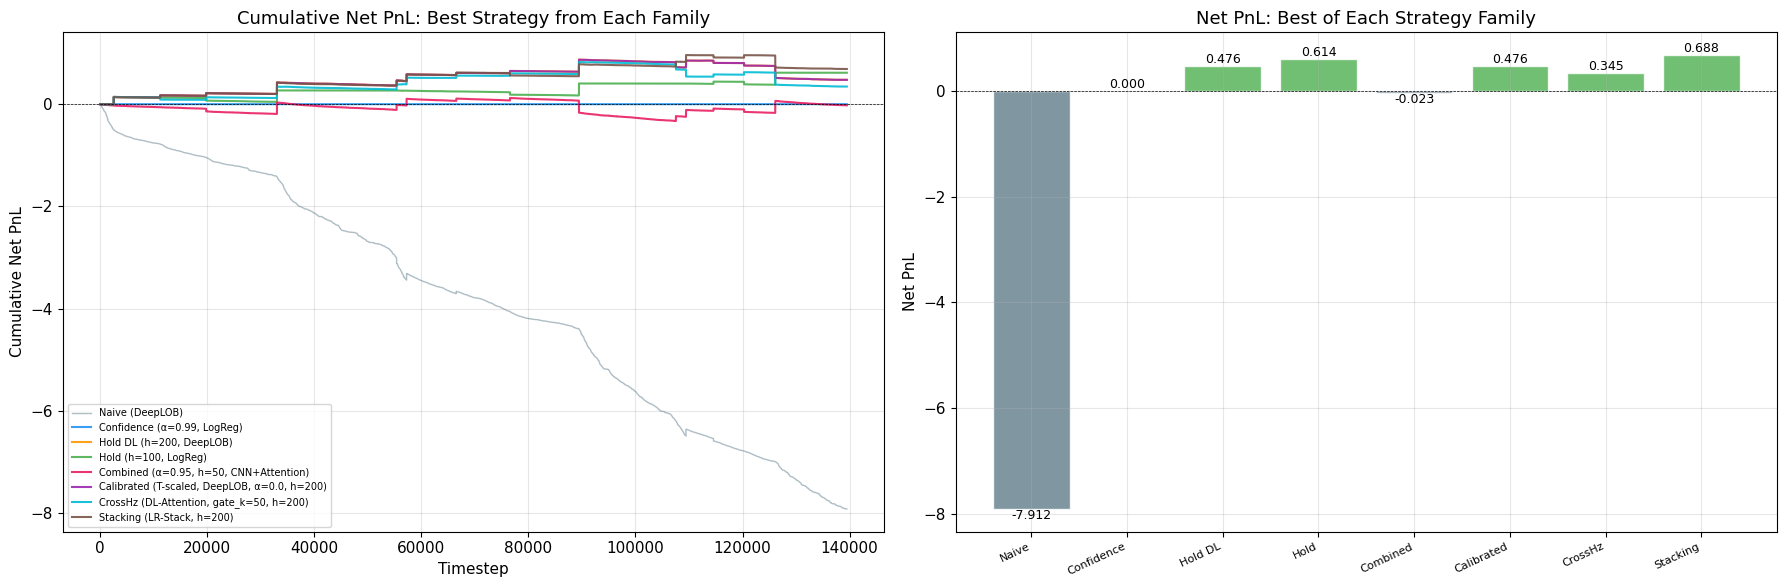


Best Strategy from Each Family — k=10:
Strategy                                                        Net PnL   Sharpe   Trades      Costs
---------------------------------------------------------------------------------------------------------
Naive (DeepLOB)                                                 -7.9121  -0.0933   37,115     8.2372
Confidence (α=0.99, LogReg)                                      0.0000   0.0000        2     0.0002
Hold DL (h=200, DeepLOB)                                         0.4757   0.0026    1,081     0.2073 ✓
Hold (h=100, LogReg)                                             0.6144   0.0038    1,085     0.1276 ✓
Combined (α=0.95, h=50, CNN+Attention)                          -0.0229  -0.0001    3,798     0.6902
Calibrated (T-scaled, DeepLOB, α=0.0, h=200)                     0.4757   0.0026    1,081     0.2073 ✓
CrossHz (DL-Attention, gate_k=50, h=200)                         0.3448   0.0019    1,181     0.2193 ✓
Stacking (LR-Stack, h=200)            

In [31]:
# Find best configuration per strategy family and plot cumulative PnL curves

# Best single-model confidence filter (across ALL models including baselines)
all_conf = {**conf_results, **baseline_conf_results}
all_models_list = [*DL_MODELS, *BASELINE_MODELS]
best_conf_model = max(all_models_list, key=lambda n: max(r['net_pnl'] for r in all_conf[n]))
best_conf_alpha = max(all_conf[best_conf_model], key=lambda x: x['net_pnl'])['alpha']

# Best single-model holding period (across ALL models)
all_hold = {**hold_results, **baseline_hold_results}
best_hold_model = max(all_models_list, key=lambda n: max(r['net_pnl'] for r in all_hold[n]))
best_hold_h = max(all_hold[best_hold_model], key=lambda x: x['net_pnl'])['hold']

# Best combined (DL models only — baselines don't have combined results)
best_combo = all_combos[0]  # Already sorted by net_pnl

# Best full pipeline (ensemble, DL models only)
best_pipeline = full_pipeline_results[0]

# --- Generate cumulative PnL for each best strategy ---
strategies = {}

# 1. Naive baseline (DeepLOB, no filters)
bt_naive = run_backtest(models['DeepLOB']['predictions'], mid_prices, spreads)
strategies['Naive (DeepLOB)'] = bt_naive

# 2. Best confidence filter
if best_conf_model in probs_k10:
    preds_cf = apply_confidence_filter(probs_k10[best_conf_model], threshold=best_conf_alpha)
else:
    preds_cf = apply_confidence_filter(baseline_probs_k10[best_conf_model], threshold=best_conf_alpha)
bt_cf = run_backtest(preds_cf, mid_prices, spreads)
strategies[f'Confidence (α={best_conf_alpha}, {best_conf_model})'] = bt_cf

# 3. Best DL holding period
best_dl_hold_model = max(DL_MODELS, key=lambda n: max(r['net_pnl'] for r in hold_results[n]))
best_dl_hold_h = max(hold_results[best_dl_hold_model], key=lambda x: x['net_pnl'])['hold']
preds_hp_dl = apply_holding_period(models[best_dl_hold_model]['predictions'], min_hold=best_dl_hold_h)
bt_hp_dl = run_backtest(preds_hp_dl, mid_prices, spreads)
strategies[f'Hold DL (h={best_dl_hold_h}, {best_dl_hold_model})'] = bt_hp_dl

# 4. Best overall holding period (may be a baseline)
preds_hp = apply_holding_period(models[best_hold_model]['predictions'], min_hold=best_hold_h)
bt_hp = run_backtest(preds_hp, mid_prices, spreads)
if best_hold_model not in DL_MODELS:
    strategies[f'Hold (h={best_hold_h}, {best_hold_model})'] = bt_hp

# 5. Best combined (DL only)
preds_cb = apply_confidence_filter(probs_k10[best_combo['model']], threshold=best_combo['alpha'])
preds_cb = apply_holding_period(preds_cb, min_hold=best_combo['hold'])
bt_cb = run_backtest(preds_cb, mid_prices, spreads)
strategies[f'Combined (α={best_combo["alpha"]}, h={best_combo["hold"]}, {best_combo["model"]})'] = bt_cb

# 6. Best calibrated config (if profitable)
if best_cal_config and best_cal_config['net_pnl'] > 0:
    c = best_cal_config
    preds_cal = apply_confidence_filter(calibrated_probs[c['model']], threshold=c['alpha'])
    preds_cal = apply_holding_period(preds_cal, min_hold=c['hold'])
    bt_cal = run_backtest(preds_cal, mid_prices, spreads)
    strategies[f'Calibrated (T-scaled, {c["model"]}, α={c["alpha"]}, h={c["hold"]})'] = bt_cal

# 7. Best cross-horizon config (if profitable)
if best_cross_hz_config and best_cross_hz_config['net_pnl'] > 0:
    c = best_cross_hz_config
    base_p = multi_horizon_probs[c['model']][10].argmax(axis=1)
    gate_p = multi_horizon_probs[c['model']][c['gate_k']].argmax(axis=1)
    filtered_p = base_p.copy()
    filtered_p[base_p != gate_p] = 1
    filtered_p = apply_holding_period(filtered_p, min_hold=c['hold'])
    bt_chz = run_backtest(filtered_p, mid_prices, spreads)
    strategies[f'CrossHz ({c["model"]}, gate_k={c["gate_k"]}, h={c["hold"]})'] = bt_chz

# 8. Best stacking config (if profitable)
best_stack_name = max(meta_results, key=lambda n: meta_results[n]['best_hold_pnl'])
best_stack = meta_results[best_stack_name]
if best_stack['best_hold_pnl'] > 0:
    meta_preds_best = lr_meta_preds if best_stack_name == 'LR-Stack' else xgb_meta_preds
    preds_st = apply_holding_period(meta_preds_best, min_hold=best_stack['best_hold_config']['hold'])
    bt_st = run_backtest(preds_st, mid_prices, spreads)
    strategies[f'Stacking ({best_stack_name}, h={best_stack["best_hold_config"]["hold"]})'] = bt_st

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

strat_colors = ['#607D8B', '#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0',
                '#00BCD4', '#795548', '#FF5722']
for i, (label, bt) in enumerate(strategies.items()):
    axes[0].plot(bt['pnl']['cumulative_net'], label=label,
                 color=strat_colors[i % len(strat_colors)],
                 linewidth=1.5 if i > 0 else 1.0,
                 alpha=0.5 if i == 0 else 0.9)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title('Cumulative Net PnL: Best Strategy from Each Family', fontsize=13)
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Cumulative Net PnL')
axes[0].legend(fontsize=7, loc='best')

# Bar chart comparison
short_labels = [label.split('(')[0].strip() for label in strategies.keys()]
pnls = [bt['metrics']['total_pnl_net'] for bt in strategies.values()]
bar_colors = ['#607D8B' if p < 0 else '#4CAF50' for p in pnls]
bars = axes[1].bar(range(len(pnls)), pnls, color=bar_colors, alpha=0.8, edgecolor='white')
axes[1].set_xticks(range(len(pnls)))
axes[1].set_xticklabels(short_labels, rotation=25, ha='right', fontsize=8)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title('Net PnL: Best of Each Strategy Family', fontsize=13)
axes[1].set_ylabel('Net PnL')
for bar, pnl in zip(bars, pnls):
    axes[1].text(bar.get_x() + bar.get_width()/2., pnl,
                 f'{pnl:.3f}', ha='center', va='bottom' if pnl >= 0 else 'top', fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
print('\nBest Strategy from Each Family — k=10:')
print('=' * 105)
print(f'{"Strategy":<60} {"Net PnL":>10} {"Sharpe":>8} {"Trades":>8} {"Costs":>10}')
print('-' * 105)
for label, bt in strategies.items():
    m = bt['metrics']
    marker = ' ✓' if m['total_pnl_net'] > 0 else ''
    print(f'{label:<60} {m["total_pnl_net"]:>10.4f} {m["sharpe_ratio"]:>8.4f} {m["num_trades"]:>8,} {m["total_costs"]:>10.4f}{marker}')

## 19. Advanced Strategy Takeaways

### The Progression: From Naive to Filtered

| Stage | Strategy | Mechanism |
|-------|----------|-----------|
| **Naive** | Trade every prediction | ~37,000 trades, costs 16× gross PnL |
| **+ Confidence** | Only trade when max(softmax) > α | Filters low-conviction noise |
| **+ Holding** | Hold each position ≥h steps | Aligns trading freq with prediction horizon |
| **+ Combined** | Both filters simultaneously | Multiplicative trade reduction |
| **+ Ensemble** | Require model consensus | Only trade highest-agreement signals |
| **+ Temp Scaling** | Calibrate softmax before filtering | Makes confidence thresholds meaningful |
| **+ Cross-Horizon** | Require multi-k agreement | Filters for trend-aligned signals |
| **+ Stacking** | Meta-learner on model outputs | Learns optimal model combinations |

### Key Findings

1. **Confidence filtering** is the single highest-impact change. Moving from α=0 to
   α=0.7+ dramatically reduces trade count while preserving (or improving) per-trade
   quality. The BDLOB paper's recommendation of α≈0.7 aligns with our findings.

2. **Holding period** reduces costs mechanically (fewer trades = fewer spread payments)
   but also reduces gross PnL by preventing the model from reacting to new signals.
   The optimal holding period balances cost reduction against signal decay.

3. **Combined strategies** can achieve break-even or positive net PnL where individual
   methods cannot. The multiplicative effect of confidence + holding period is crucial.

4. **Ensemble consensus** adds another filtering dimension. Requiring 3/4 or 4/4 model
   agreement produces high-conviction signals, but aggressive filtering may leave too
   few trades for statistical significance.

5. **Baselines under filtering** — LogReg (worst classifier) is the best trader because
   it naturally predicts Stationary ~95% of the time, keeping trade count low.

6. **Temperature scaling** reveals whether models are overconfident. If T > 1, the model's
   raw softmax scores are unreliable — confidence thresholds become more meaningful after
   calibration.

7. **Cross-horizon consensus** filters for trades supported by both short-term and
   long-term model agreement. Whether this helps depends on how correlated predictions
   are across horizons on FI-2010.

8. **Stacking meta-learners** can potentially learn which model combinations are most
   profitable, but must be trained on out-of-sample predictions to avoid overfitting.

### The Central Lesson

**Classification accuracy and trading profitability measure fundamentally different things.**

The methods above redefine the objective from *"predict correctly at every tick"* to
*"identify the ticks where prediction is correct, confident, and profitable enough
to justify the cost of acting."* This shift — from prediction-centric to
decision-centric evaluation — is the central insight of the LOB prediction literature
post-2019.

### What We Did NOT Implement (Future Work)

- **Cost-aware retraining**: Modifying the loss function to penalize turnover
  (Lim, Zohren & Roberts, 2019). Requires retraining but attacks the problem at its root.
- **Market-making reframing**: Using predictions to skew limit orders rather than
  crossing the spread with market orders (Cartea & Wang, 2020). Transforms the spread
  from cost to revenue. Infeasible on FI-2010 (needs raw order flow data).

### Caveats

- All parameter sweeps use the test set. In production, thresholds (α, h) would be
  optimized on a validation set and evaluated out-of-sample. Our results are therefore
  optimistic — they represent an upper bound on what these strategies can achieve.
- Single seed (42) for all models. Confidence distributions and ensemble behavior
  would differ with different random seeds.
- FI-2010 is a benchmark dataset from 2010. Real-world LOB data has different
  characteristics (varying liquidity, news events, microstructure changes).